# The Maltese Traffic Sign Dataset (MTSD) — Exploratory Data Analysis

**MSc Dissertation · University of Malta**

This notebook presents a systematic exploratory analysis of the Maltese Traffic Sign Dataset
(MTSD), a smartphone-collected image corpus of traffic signs and street furniture captured
across Malta and Gozo. The analysis characterises the dataset along four axes:

1. the **image collection** itself (formats, geometry, file properties);
2. the **acquisition process** (devices, optics, exposure settings, capture conditions);
3. the **spatial and temporal footprint** of the collection campaign; and
4. the **QA-verified annotations** (class balance, bounding-box geometry, auxiliary
   attributes, class-attribute and attribute-attribute structure, the geographic
   distribution of sign condition, and annotation quality).

Each figure is exported at 300 dpi to `Documents/MTSD-EDA/Figures/` and every summary table
to `Documents/MTSD-EDA/GeneratedCSVs/`, so all artefacts can be referenced directly from the
dissertation text.

### Methodological notes

- **The dataset is analysed as a single corpus.** The `GRP-*` folders exist only because the
  collection was partitioned for distribution to third-party annotators; the partitioning
  carries no analytical meaning and is deliberately ignored throughout (it is retained solely
  as file-system provenance).
- **Only the QA-verified annotation exports** (`QA-GRP*.json`) are used as annotation ground
  truth. Raw annotator outputs are never read.
- **Reproducibility.** All statistics derive from two inputs: a cached image-metadata
  inventory (rebuildable from the raw images with `FORCE_RESCAN = True`) and the QA JSON
  files. Re-running the notebook top-to-bottom regenerates every figure and table.

### Contents

1. [Setup and configuration](#1-Setup-and-configuration)
2. [Data loading and corpus overview](#2-Data-loading-and-corpus-overview)
3. [Image collection characteristics](#3-Image-collection-characteristics)
4. [Acquisition devices and camera settings](#4-Acquisition-devices-and-camera-settings)
5. [Geospatial analysis](#5-Geospatial-analysis)
6. [Temporal analysis](#6-Temporal-analysis)
7. [Annotation analysis](#7-Annotation-analysis)
8. [Dataset summary and discussion](#8-Dataset-summary-and-discussion)
9. [Exported artefacts](#9-Exported-artefacts)


## 1. Setup and configuration

The analysis depends only on the scientific Python stack plus the local `mtsd_eda` support
package (image scanning, COCO loading, geodesic helpers, and the figure style). Library
versions are printed for the record.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

if not any((Path(p) / "mtsd_eda").is_dir() for p in sys.path if p):
    sys.path.insert(0, str(Path.cwd()))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter

from mtsd_eda import annotations as annlib
from mtsd_eda import coco, config, geo, inventory, plotstyle

plotstyle.apply()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"{'Python':<12} {sys.version.split()[0]}")
for module in (np, pd, mpl):
    print(f"{module.__name__:<12} {module.__version__}")
print(f"{'Repository':<12} {config.BASE_DIR}")


Python       3.12.11
numpy        2.0.1
pandas       2.3.3
matplotlib   3.10.6
Repository   E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark


In [2]:
# Reproducibility switches ----------------------------------------------------
# FORCE_RESCAN=True re-reads every image header from disk (~30 s on an SSD);
# when False, the cached inventory CSV is reused if present.
FORCE_RESCAN = False
COMPUTE_HASHES = True        # perceptual hashes are required for duplicate detection
NEAR_DUPLICATE_BITS = 2      # max dHash Hamming distance treated as a near-duplicate
MIN_CLASS_SAMPLE = 50        # classes below this are flagged (*) in per-class percentage views
MIN_LOCALITY_ANNOTATIONS = 30  # localities below this are flagged in percentage rankings

config.ensure_output_dirs()
print(f"Figure output : {config.FIGURES_DIR}")
print(f"CSV output    : {config.CSV_DIR}")


Figure output : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA\Figures
CSV output    : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA\GeneratedCSVs


## 2. Data loading and corpus overview

Two independent sources are loaded:

- the **image inventory** — one record per file found under `Datasets/MTSD/GRP-*`, with
  dimensions, EXIF camera metadata, GPS coordinates, capture timestamps, and a 64-bit
  perceptual hash; and
- the **QA-verified annotation set** — every `QA-GRP*.json` COCO export merged into a
  single table with globally unique identifiers.

The annotated subset is expected to grow as further QA batches are signed off; all
statistics below are computed from whatever QA files are present at run time.


In [3]:
inv = inventory.build_inventory(force=FORCE_RESCAN, compute_hash=COMPUTE_HASHES)
readable = inv[~inv["is_corrupted"]].copy()

qa_images, qa_anns, qa_cats = coco.load_qa_dataset()
qa_files = coco.discover_qa_files()

print(f"Images on disk      : {len(inv):,}")
print(f"Readable            : {len(readable):,}")
print(f"Unreadable/corrupted: {int(inv['is_corrupted'].sum()):,}")
print(f"QA annotation files : {', '.join(p.name for p in qa_files)}")
print(f"QA-verified images  : {len(qa_images):,}")
print(f"QA annotations      : {len(qa_anns):,}")


Images on disk      : 7,492
Readable            : 7,492
Unreadable/corrupted: 0
QA annotation files : QA-GRP1.json, QA-GRP2.json, QA-GRP3.json, QA-GRP4.json, QA-GRP5.json, QA-GRP6.json, QA-GRP7.json, QA-GRP8.json, QA-GRP9.json, QA-GRP10.json, QA-GRP11.json
QA-verified images  : 7,492
QA annotations      : 20,536


In [4]:
timestamped = readable.dropna(subset=["datetime_original"])
capture_window = (
    f"{timestamped['datetime_original'].min():%d %b %Y} - "
    f"{timestamped['datetime_original'].max():%d %b %Y}"
) if len(timestamped) else "n/a"

overview = pd.DataFrame(
    [
        ("Images on disk", f"{len(inv):,}"),
        ("Readable images", f"{len(readable):,}"),
        ("Total volume", f"{inv['file_size_bytes'].sum() / 1024**3:,.2f} GiB"),
        ("Images with EXIF metadata", f"{int(readable['has_exif'].sum()):,}"
         f"  ({readable['has_exif'].mean():.1%})"),
        ("Images with GPS coordinates", f"{int(readable['has_gps'].sum()):,}"
         f"  ({readable['has_gps'].mean():.1%})"),
        ("Images with capture timestamp", f"{len(timestamped):,}"
         f"  ({len(timestamped) / len(readable):.1%})"),
        ("Capture window", capture_window),
        ("QA-verified images", f"{len(qa_images):,}"),
        ("QA-verified annotations", f"{len(qa_anns):,}"),
        ("Annotation classes", f"{len(qa_cats)}"),
    ],
    columns=["Metric", "Value"],
)
overview.to_csv(config.CSV_DIR / "dataset_overview.csv", index=False)
overview.style.hide(axis="index")


Metric,Value
Images on disk,"7,492"
Readable images,"7,492"
Total volume,20.76 GiB
Images with EXIF metadata,"5,759 (76.9%)"
Images with GPS coordinates,"4,228 (56.4%)"
Images with capture timestamp,"5,432 (72.5%)"
Capture window,06 Nov 2025 - 31 Jan 2026
QA-verified images,"7,492"
QA-verified annotations,"20,536"
Annotation classes,12


## 3. Image collection characteristics

### 3.1 File formats and sizes

Smartphone cameras write plain JPEG, MPO (a JPEG container with an embedded depth/secondary
frame, produced by several Android devices), or PNG (typically screenshots or edited
exports). MPO files behave exactly like JPEG for all downstream tooling — the primary frame
is a standard JPEG image.


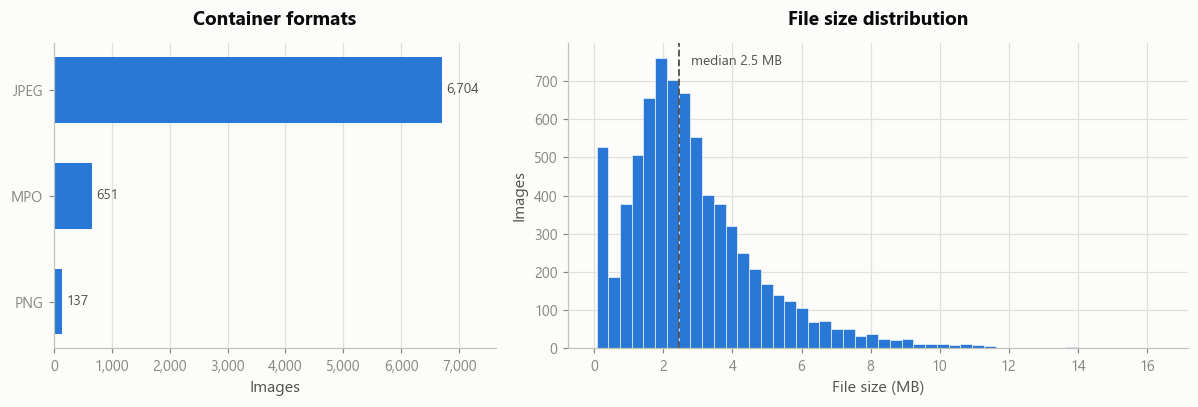

Total volume  : 20.76 GiB
Mean file size: 2.84 MB   median: 2.46 MB   IQR: 1.58-3.69 MB


In [5]:
format_counts = readable["format"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})

bars = axes[0].barh(format_counts.index[::-1], format_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[0], bars)
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Container formats")
axes[0].set_xlabel("Images")
axes[0].xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
axes[0].margins(x=0.14)

sizes = readable["file_size_mb"]
axes[1].hist(sizes, bins=48, color=plotstyle.ACCENT, edgecolor=plotstyle.SURFACE,
             linewidth=0.4)
axes[1].axvline(sizes.median(), color=plotstyle.INK_SECONDARY, linewidth=1.2,
                linestyle="--")
axes[1].annotate(f"median {sizes.median():.1f} MB",
                 xy=(sizes.median(), 1), xycoords=("data", "axes fraction"),
                 xytext=(8, -14), textcoords="offset points",
                 color=plotstyle.INK_SECONDARY, fontsize=9)
axes[1].set_title("File size distribution")
axes[1].set_xlabel("File size (MB)")
axes[1].set_ylabel("Images")
axes[1].yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))

fig.tight_layout()
plotstyle.save_fig(fig, "fig01_formats_and_file_size")
plt.show()

print(f"Total volume  : {readable['file_size_bytes'].sum() / 1024**3:.2f} GiB")
print(f"Mean file size: {sizes.mean():.2f} MB   median: {sizes.median():.2f} MB   "
      f"IQR: {sizes.quantile(0.25):.2f}-{sizes.quantile(0.75):.2f} MB")


### 3.2 Resolution, aspect ratio, and orientation

Pixel dimensions below are **display-corrected**: where the EXIF orientation tag indicates a
90° stored rotation, width and height are swapped so that portrait captures are counted as
portrait. The resolution landscape shows every distinct (width × height) combination in the
corpus; the marker area is proportional to the number of images.


C:\Users\fridge\AppData\Local\Temp\ipykernel_32532\941135542.py:16: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.tight_layout()
E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Scripts\MTSD-Scripts\MTSD-Analysis\mtsd_eda\plotstyle.py:97: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.savefig(target)
C:\Users\fridge\anaconda3\envs\MDWD\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


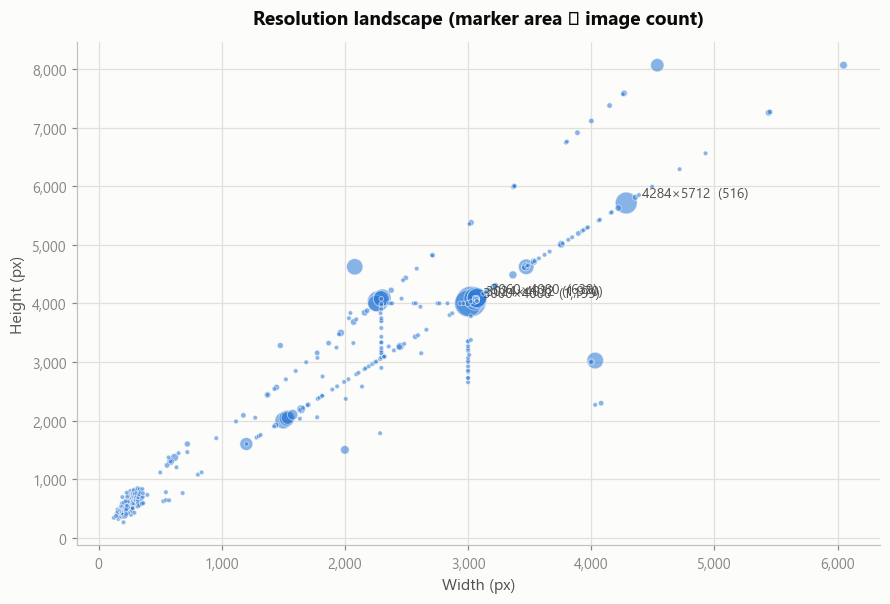

Distinct resolutions: 364
 width  height  count
  3024    4032   1970
  3000    4000   1199
  3060    4080    639
  4284    5712    516
  2268    4032    441
  3072    4080    348
  3072    4096    330
  2304    4096    213


In [6]:
res = (readable.groupby(["width", "height"]).size()
       .reset_index(name="count").sort_values("count", ascending=False))

fig, ax = plt.subplots(figsize=(8.2, 5.6))
ax.scatter(res["width"], res["height"], s=np.sqrt(res["count"]) * 9,
           color=plotstyle.ACCENT, alpha=0.55, edgecolor=plotstyle.SURFACE, linewidth=0.6)
for _, row in res.head(4).iterrows():
    ax.annotate(f"{row['width']:.0f}×{row['height']:.0f}  ({row['count']:,})",
                xy=(row["width"], row["height"]), xytext=(10, 4),
                textcoords="offset points", fontsize=9, color=plotstyle.INK_SECONDARY)
ax.set_title("Resolution landscape (marker area ∝ image count)")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig02_resolution_landscape")
plt.show()

print(f"Distinct resolutions: {len(res)}")
print(res.head(8).to_string(index=False))


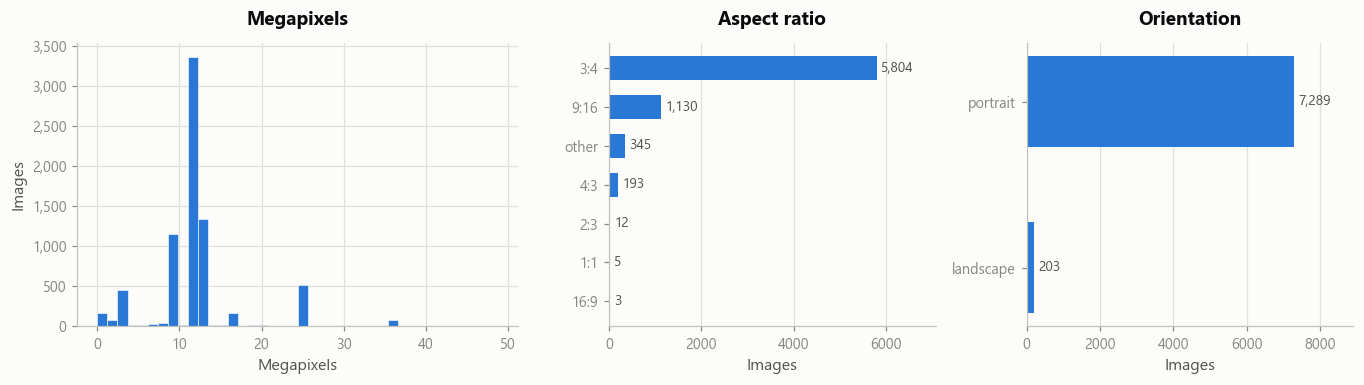

Median resolution : 3024×4032 px
Megapixels        : mean 12.1, median 12.2, range 0.0-48.8
Portrait share    : 97.3%


In [7]:
def nearest_ratio(value: float) -> str:
    named = {"3:4": 3/4, "4:3": 4/3, "9:16": 9/16, "16:9": 16/9,
             "1:1": 1.0, "2:3": 2/3, "3:2": 3/2}
    name, ratio = min(named.items(), key=lambda item: abs(item[1] - value))
    return name if abs(ratio - value) / ratio < 0.05 else "other"

readable["aspect_class"] = readable["aspect_ratio"].map(nearest_ratio)
aspect_counts = readable["aspect_class"].value_counts()
orient_counts = readable["orientation"].value_counts()
mp = readable["megapixels"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6),
                         gridspec_kw={"width_ratios": [1.35, 1, 1]})

axes[0].hist(mp, bins=40, color=plotstyle.ACCENT, edgecolor=plotstyle.SURFACE,
             linewidth=0.4)
axes[0].set_title("Megapixels")
axes[0].set_xlabel("Megapixels")
axes[0].set_ylabel("Images")
axes[0].yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))

bars = axes[1].barh(aspect_counts.index[::-1], aspect_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[1], bars)
plotstyle.style_h_barh(axes[1])
axes[1].set_title("Aspect ratio")
axes[1].set_xlabel("Images")
axes[1].margins(x=0.22)

bars = axes[2].barh(orient_counts.index[::-1], orient_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.55)
plotstyle.bar_value_labels(axes[2], bars)
plotstyle.style_h_barh(axes[2])
axes[2].set_title("Orientation")
axes[2].set_xlabel("Images")
axes[2].margins(x=0.22)

fig.tight_layout()
plotstyle.save_fig(fig, "fig03_geometry_profile")
plt.show()

print(f"Median resolution : {readable['width'].median():.0f}×{readable['height'].median():.0f} px")
print(f"Megapixels        : mean {mp.mean():.1f}, median {mp.median():.1f}, "
      f"range {mp.min():.1f}-{mp.max():.1f}")
print(f"Portrait share    : {orient_counts.get('portrait', 0) / len(readable):.1%}")


## 4. Acquisition devices and camera settings

EXIF metadata identifies the capturing hardware and exposure parameters. Because the corpus
was gathered by multiple volunteers on personal smartphones, device diversity is a genuine
property of the dataset — it broadens the sensor/optics distribution but also implies
heterogeneous colour rendition and sharpness. Images without EXIF (e.g. exports through
messaging apps that strip metadata) are reported as *unknown*.


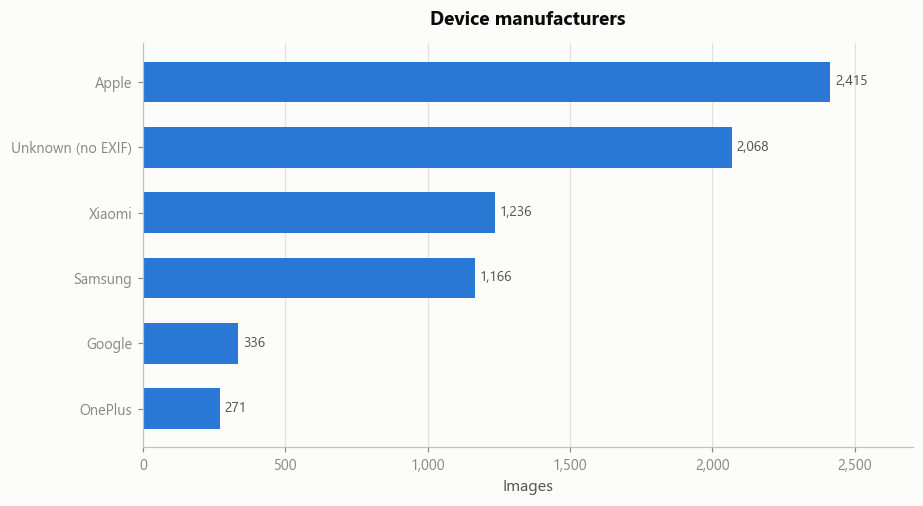

In [8]:
MAKE_ALIASES = {"Samsung": "Samsung", "Oneplus": "OnePlus", "Xiaomi": "Xiaomi"}
readable["make_norm"] = (
    readable["camera_make"].str.strip().str.title().replace(MAKE_ALIASES)
)
make_counts = readable["make_norm"].fillna("Unknown (no EXIF)").value_counts()

fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(make_counts) + 1.4))
bars = ax.barh(make_counts.index[::-1], make_counts.values[::-1],
               color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title("Device manufacturers")
ax.set_xlabel("Images")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.12)
fig.tight_layout()
plotstyle.save_fig(fig, "fig04_manufacturers")
plt.show()


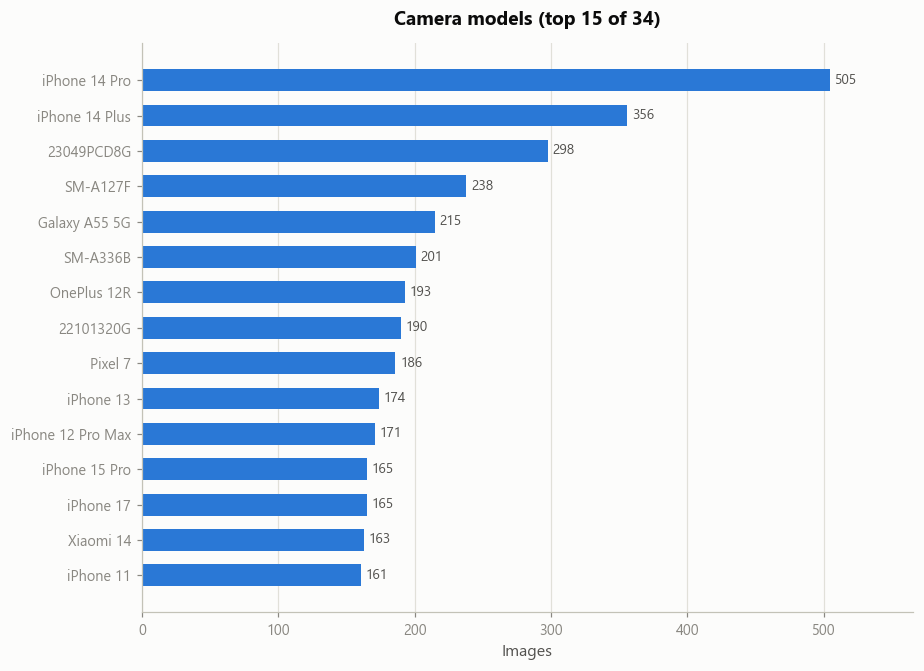

Distinct models: 34  (top model covers 6.7% of the corpus)


In [9]:
model_counts = (readable.dropna(subset=["camera_model"])
                .groupby(["make_norm", "camera_model"]).size()
                .sort_values(ascending=False))
top_models = model_counts.head(15)
labels = [f"{model}" for (_, model) in top_models.index][::-1]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
bars = ax.barh(labels, top_models.values[::-1], color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title(f"Camera models (top {len(top_models)} of {model_counts.size})")
ax.set_xlabel("Images")
ax.margins(x=0.12)
fig.tight_layout()
plotstyle.save_fig(fig, "fig05_camera_models")
plt.show()

device_summary = model_counts.reset_index()
device_summary.columns = ["manufacturer", "camera_model", "images"]
device_summary.to_csv(config.CSV_DIR / "device_summary.csv", index=False)
print(f"Distinct models: {model_counts.size}  "
      f"(top model covers {top_models.iloc[0] / len(readable):.1%} of the corpus)")


### 4.1 Optics and exposure

The three panels below profile the *photographic* conditions: 35 mm-equivalent focal length
(lens selection), aperture (fixed per lens on phones), and ISO sensitivity (the camera's
response to available light). Exposure time is summarised separately against time of day,
which acts as a proxy for ambient illumination during the collection campaign.


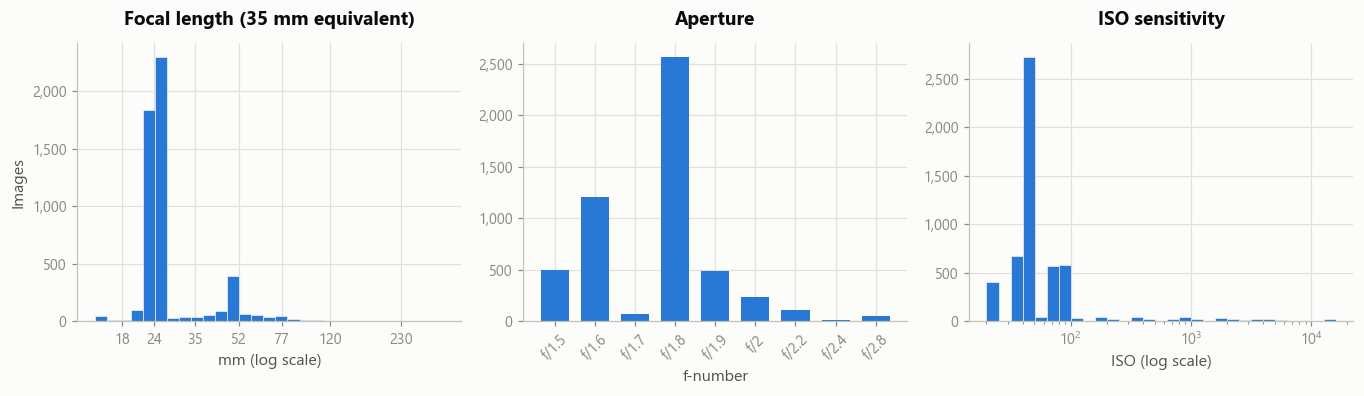

Focal length : median 25 mm equivalent
Aperture     : f/1.5 - f/2.8
ISO          : median 50, p95 400, max 16000
Exposure time: median 1/1332, longest 1/4
Flash fired  : 17 of 5,243 EXIF images (0.32%)


In [10]:
focal = readable["focal_length_35mm"].dropna()
focal = focal[focal > 0]
apertures = readable["f_number"].dropna()
aperture_counts = apertures[apertures > 0].round(1).value_counts().sort_index()
iso = readable["iso"].dropna()
iso = iso[iso > 0]  # a handful of devices write an invalid ISO/f-number of 0

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))

focal_bins = np.geomspace(focal.min(), focal.max(), 30)
axes[0].hist(focal, bins=focal_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[0].set_xscale("log")
focal_ticks = [13, 18, 24, 35, 52, 77, 120, 230]
axes[0].set_xticks([t for t in focal_ticks if focal.min() <= t <= focal.max()])
axes[0].get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
axes[0].minorticks_off()
axes[0].set_title("Focal length (35 mm equivalent)")
axes[0].set_xlabel("mm (log scale)")
axes[0].set_ylabel("Images")

axes[1].bar([f"f/{v:g}" for v in aperture_counts.index], aperture_counts.values,
            color=plotstyle.ACCENT, width=0.7)
axes[1].set_title("Aperture")
axes[1].set_xlabel("f-number")
axes[1].tick_params(axis="x", rotation=45)

iso_bins = np.geomspace(iso.min(), iso.max(), 30)
axes[2].hist(iso, bins=iso_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[2].set_xscale("log")
axes[2].set_title("ISO sensitivity")
axes[2].set_xlabel("ISO (log scale)")

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig06_optics_exposure")
plt.show()

exp = readable["exposure_time_s"].dropna()
exp = exp[exp > 0]
print(f"Focal length : median {focal.median():.0f} mm equivalent")
print(f"Aperture     : f/{aperture_counts.index.min():g} - f/{aperture_counts.index.max():g}")
print(f"ISO          : median {iso.median():.0f}, p95 {iso.quantile(0.95):.0f}, max {iso.max():.0f}")
print(f"Exposure time: median {inventory.exposure_fraction(exp.median())}, "
      f"longest {inventory.exposure_fraction(exp.max())}")
flash = readable["flash_fired"].dropna()
print(f"Flash fired  : {int(flash.sum()):,} of {len(flash):,} EXIF images ({flash.mean():.2%})")


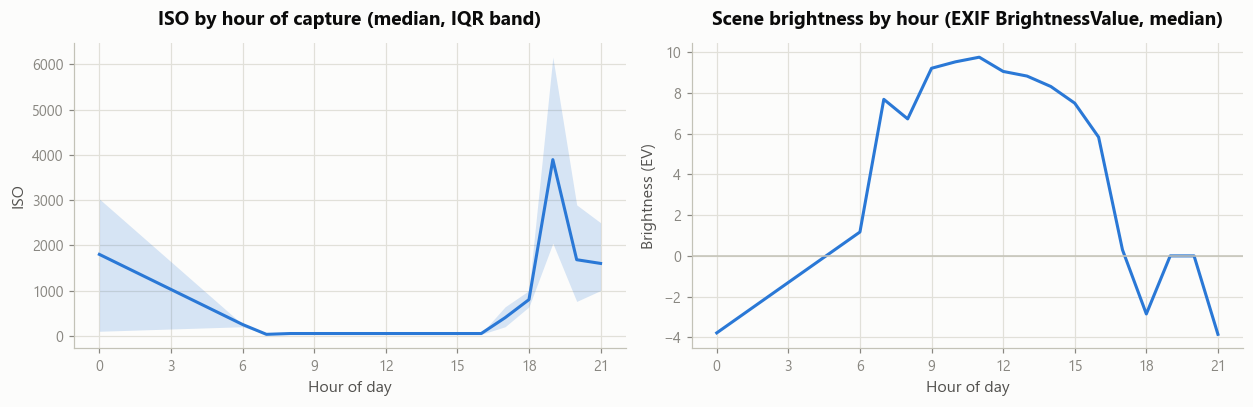

Captures between 07:00 and 17:59: 95.5% - the corpus is predominantly a daylight collection; low-light captures show the expected ISO rise.


In [11]:
timed = readable.dropna(subset=["datetime_original"]).copy()
timed["hour"] = timed["datetime_original"].dt.hour

by_hour = timed.groupby("hour").agg(
    iso_median=("iso", "median"),
    iso_q25=("iso", lambda s: s.quantile(0.25)),
    iso_q75=("iso", lambda s: s.quantile(0.75)),
    brightness=("brightness_ev", "median"),
    images=("filename", "size"),
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharex=True)
axes[0].fill_between(by_hour.index, by_hour["iso_q25"], by_hour["iso_q75"],
                     color=plotstyle.ACCENT, alpha=0.18, linewidth=0)
axes[0].plot(by_hour.index, by_hour["iso_median"], color=plotstyle.ACCENT, linewidth=2)
axes[0].set_title("ISO by hour of capture (median, IQR band)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("ISO")

axes[1].plot(by_hour.index, by_hour["brightness"], color=plotstyle.ACCENT, linewidth=2)
axes[1].axhline(0, color=plotstyle.BASELINE, linewidth=1)
axes[1].set_title("Scene brightness by hour (EXIF BrightnessValue, median)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Brightness (EV)")

for ax in axes:
    ax.set_xticks(range(0, 24, 3))
fig.tight_layout()
plotstyle.save_fig(fig, "fig07_lighting_by_hour")
plt.show()

daylight = timed["hour"].between(7, 17).mean()
print(f"Captures between 07:00 and 17:59: {daylight:.1%} - the corpus is predominantly "
      f"a daylight collection; low-light captures show the expected ISO rise.")


## 5. Geospatial analysis

GPS positions are read directly from EXIF. Points are assigned to their nearest locality
centre (approximate town centroids) and aggregated into the six statistical districts used
by Malta's National Statistics Office, giving a coarse but robust picture of regional
coverage. An interactive atlas with per-image markers is generated separately by
`Scripts/MTSD-Analysis/mtsd_mapper.py`.


In [12]:
gps = readable[readable["has_gps"]].copy()
in_malta = gps[gps["gps_latitude"].between(35.7, 36.2) &
               gps["gps_longitude"].between(14.1, 14.7)]
outliers = len(gps) - len(in_malta)

print(f"Images with GPS      : {len(gps):,} ({len(gps) / len(readable):.1%} of readable)")
print(f"Inside Malta bbox    : {len(in_malta):,}")
print(f"Outside Malta bbox   : {outliers:,}")
print(f"Latitude range       : {in_malta['gps_latitude'].min():.4f} - {in_malta['gps_latitude'].max():.4f}")
print(f"Longitude range      : {in_malta['gps_longitude'].min():.4f} - {in_malta['gps_longitude'].max():.4f}")
if "gps_altitude_m" in gps:
    alt = in_malta["gps_altitude_m"].dropna()
    print(f"Altitude (median/p95): {alt.median():.0f} m / {alt.quantile(0.95):.0f} m")


Images with GPS      : 4,228 (56.4% of readable)
Inside Malta bbox    : 4,228
Outside Malta bbox   : 0
Latitude range       : 35.8222 - 36.0714
Longitude range      : 14.2157 - 14.5455
Altitude (median/p95): 83 m / 148 m


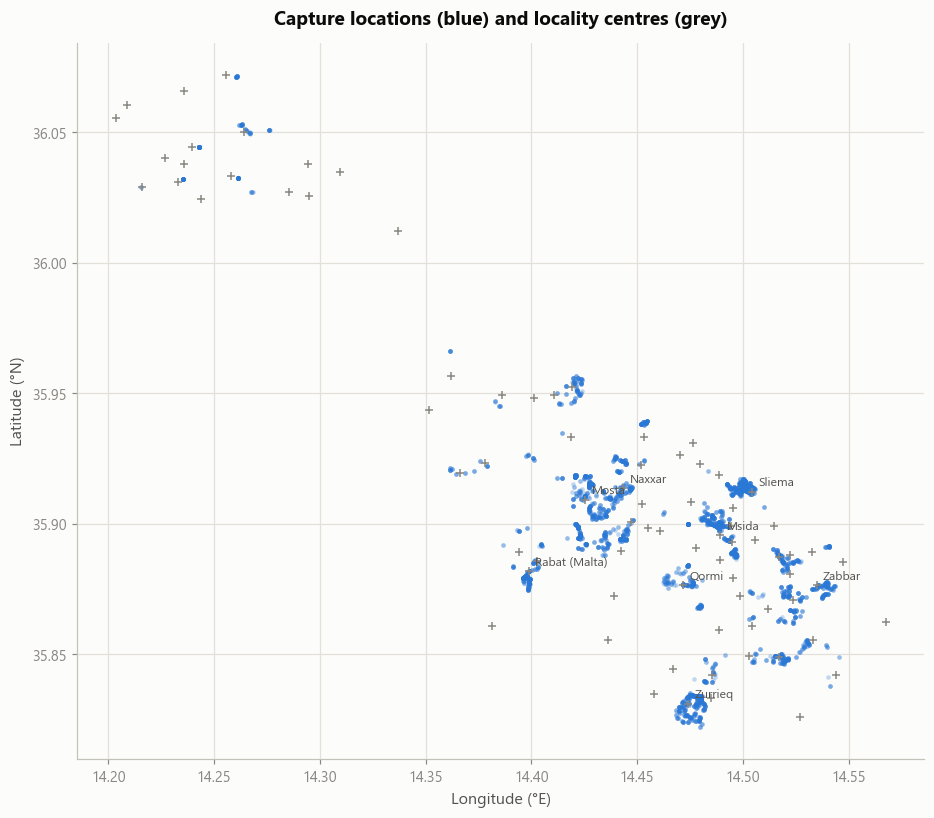

In [13]:
localised = geo.assign_localities(in_malta)

fig, ax = plt.subplots(figsize=(8.6, 7.6))
ax.scatter(localised["gps_longitude"], localised["gps_latitude"],
           s=9, color=plotstyle.ACCENT, alpha=0.28, linewidth=0)
centroids = geo.locality_frame()
ax.scatter(centroids["longitude"], centroids["latitude"], marker="+",
           s=26, color=plotstyle.INK_MUTED, linewidth=1)
for _, row in centroids.iterrows():
    if row["locality"] in localised["locality"].value_counts().head(8).index:
        ax.annotate(row["locality"], (row["longitude"], row["latitude"]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color=plotstyle.INK_SECONDARY)
ax.set_aspect(1 / np.cos(np.radians(35.9)))
ax.set_title("Capture locations (blue) and locality centres (grey)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig08_gps_scatter")
plt.show()


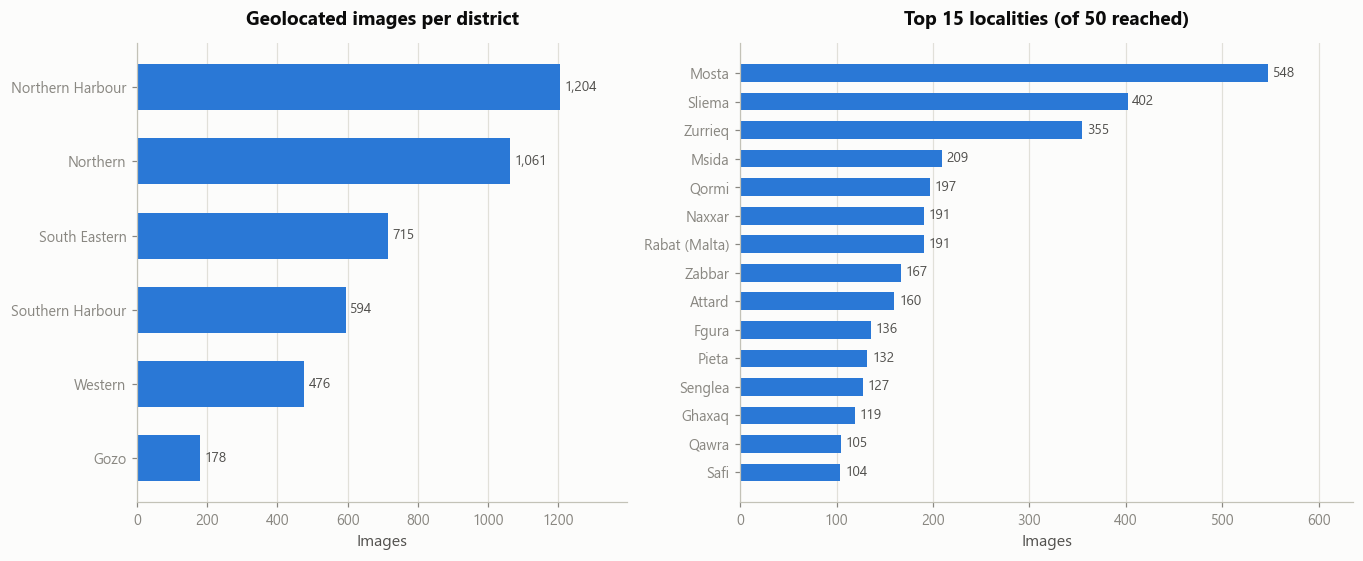

Localities reached: 50 of 79 reference centres
Gozo share        : 4.2% of geolocated captures


In [14]:
district_counts = localised["district"].value_counts()
locality_counts = localised["locality"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})

bars = axes[0].barh(district_counts.index[::-1], district_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[0], bars)
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Geolocated images per district")
axes[0].set_xlabel("Images")
axes[0].margins(x=0.16)

top_loc = locality_counts.head(15)
bars = axes[1].barh(top_loc.index[::-1], top_loc.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[1], bars)
plotstyle.style_h_barh(axes[1])
axes[1].set_title(f"Top 15 localities (of {locality_counts.size} reached)")
axes[1].set_xlabel("Images")
axes[1].margins(x=0.16)

fig.tight_layout()
plotstyle.save_fig(fig, "fig09_regional_coverage")
plt.show()

locality_summary = (localised.groupby(["district", "locality"]).size()
                    .reset_index(name="images")
                    .sort_values("images", ascending=False))
locality_summary.to_csv(config.CSV_DIR / "locality_summary.csv", index=False)
gozo_share = district_counts.get("Gozo", 0) / district_counts.sum()
print(f"Localities reached: {locality_counts.size} of {len(centroids)} reference centres")
print(f"Gozo share        : {gozo_share:.1%} of geolocated captures")


### 5.1 Interactive density map

The embedded map below gives an interactive view of capture density (requires `folium`; the
cell degrades gracefully when the package is unavailable). For marker-level browsing with
image previews, use the standalone atlas produced by `mtsd_mapper.py`.


In [15]:
try:
    import folium
    from folium.plugins import HeatMap

    fmap = folium.Map(location=[35.94, 14.38], zoom_start=11, tiles="CartoDB positron",
                      attr="CartoDB")
    HeatMap(localised[["gps_latitude", "gps_longitude"]].values.tolist(),
            radius=11, blur=14, min_opacity=0.25).add_to(fmap)
    display(fmap)
except ImportError:
    print("folium is not installed - skipping the interactive map "
          "(pip install -r Requirements/requirements-general-tooling.txt).")


folium is not installed - skipping the interactive map (pip install -r Requirements/requirements-general-tooling.txt).


## 6. Temporal analysis

Capture timestamps (EXIF `DateTimeOriginal`) describe the collection campaign itself: its
duration, intensity, and weekly/diurnal rhythm. Note that images whose EXIF was stripped
(e.g. by messaging apps) carry no timestamp and are excluded from this section.


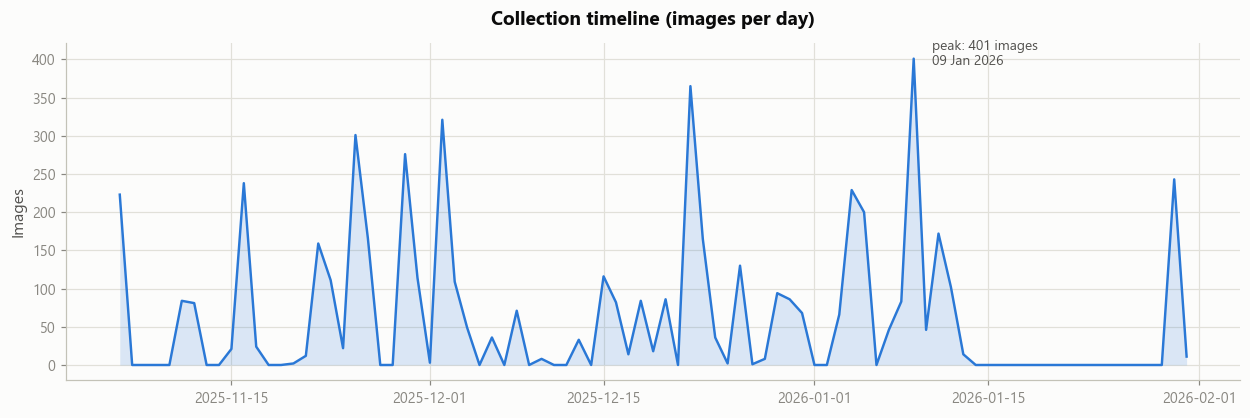

Campaign span : 87 days (06 Nov 2025 - 31 Jan 2026)
Active days   : 51 (59% of the span)  median on active days: 83 images


In [16]:
daily = timed.set_index("datetime_original").sort_index()
per_day = daily.resample("D").size()

fig, ax = plt.subplots(figsize=(11.5, 3.9))
ax.fill_between(per_day.index, per_day.values, color=plotstyle.ACCENT, alpha=0.16,
                linewidth=0)
ax.plot(per_day.index, per_day.values, color=plotstyle.ACCENT, linewidth=1.6)
peak_day = per_day.idxmax()
ax.annotate(f"peak: {per_day.max():,} images\n{peak_day:%d %b %Y}",
            xy=(peak_day, per_day.max()), xytext=(12, -4), textcoords="offset points",
            fontsize=9, color=plotstyle.INK_SECONDARY)
ax.set_title("Collection timeline (images per day)")
ax.set_xlabel("")
ax.set_ylabel("Images")
fig.tight_layout()
plotstyle.save_fig(fig, "fig10_capture_timeline")
plt.show()

active_days = int((per_day > 0).sum())
span_days = (per_day.index.max() - per_day.index.min()).days + 1
print(f"Campaign span : {span_days} days ({per_day.index.min():%d %b %Y} - "
      f"{per_day.index.max():%d %b %Y})")
print(f"Active days   : {active_days} ({active_days / span_days:.0%} of the span)  "
      f"median on active days: {per_day[per_day > 0].median():.0f} images")


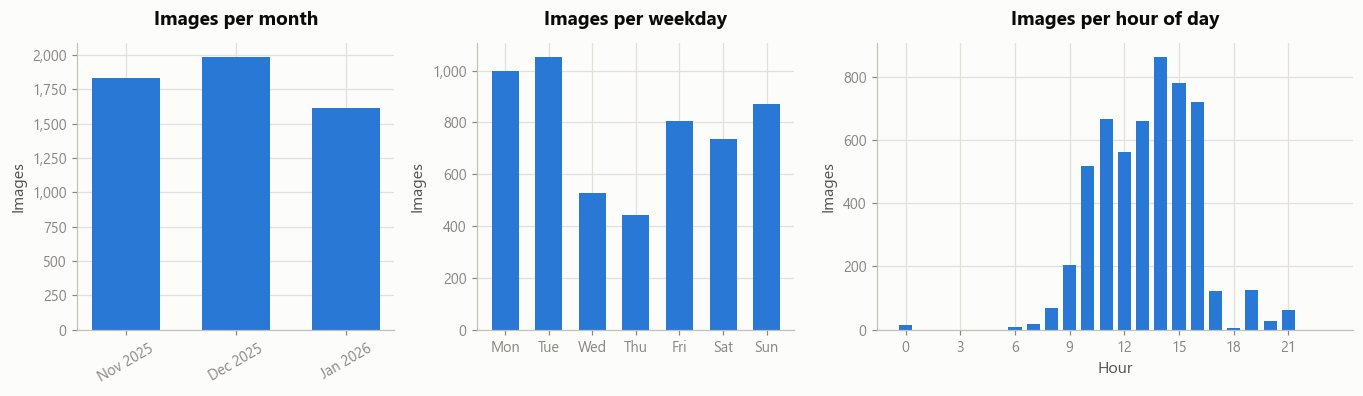

Weekend share: 29.6%   busiest hour: 14:00


In [17]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
timed["weekday"] = pd.Categorical(timed["datetime_original"].dt.strftime("%a"),
                                  categories=weekday_order, ordered=True)
timed["month"] = timed["datetime_original"].dt.strftime("%b %Y")
month_order = (timed.dropna(subset=["datetime_original"])
               .sort_values("datetime_original")["month"].unique())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7),
                         gridspec_kw={"width_ratios": [1, 1, 1.5]})

month_counts = timed["month"].value_counts().reindex(month_order)
axes[0].bar(month_counts.index, month_counts.values, color=plotstyle.ACCENT, width=0.62)
axes[0].set_title("Images per month")
axes[0].tick_params(axis="x", rotation=30)

weekday_counts = timed["weekday"].value_counts().reindex(weekday_order)
axes[1].bar(weekday_counts.index, weekday_counts.values, color=plotstyle.ACCENT, width=0.62)
axes[1].set_title("Images per weekday")

hour_counts = timed["hour"].value_counts().reindex(range(24), fill_value=0)
axes[2].bar(hour_counts.index, hour_counts.values, color=plotstyle.ACCENT, width=0.72)
axes[2].set_title("Images per hour of day")
axes[2].set_xlabel("Hour")
axes[2].set_xticks(range(0, 24, 3))

for ax in axes:
    ax.set_ylabel("Images")
    ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig11_temporal_profiles")
plt.show()

weekend_share = timed["weekday"].isin(["Sat", "Sun"]).mean()
print(f"Weekend share: {weekend_share:.1%}   busiest hour: {hour_counts.idxmax()}:00")


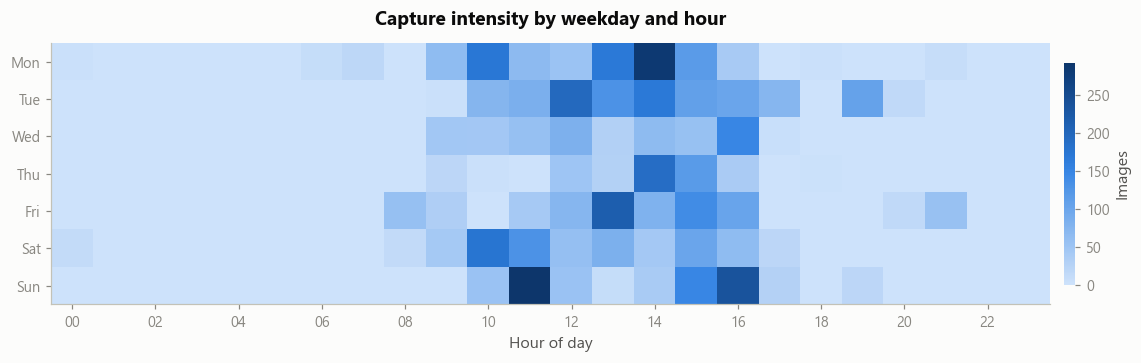

In [18]:
pivot = (timed.pivot_table(index="weekday", columns="hour", values="filename",
                           aggfunc="size", fill_value=0, observed=False)
         .reindex(weekday_order))
pivot = pivot.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(11.5, 3.4))
mesh = ax.imshow(pivot.values, aspect="auto", cmap=plotstyle.BLUES_CMAP)
ax.set_yticks(range(7), weekday_order)
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of day")
ax.set_title("Capture intensity by weekday and hour")
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, pad=0.012)
cbar.set_label("Images", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)
fig.tight_layout()
plotstyle.save_fig(fig, "fig12_weekday_hour_heatmap")
plt.show()

temporal_summary = per_day.rename("images").reset_index()
temporal_summary.columns = ["date", "images"]
temporal_summary.to_csv(config.CSV_DIR / "temporal_summary.csv", index=False)


## 7. Annotation analysis

All statistics in this section derive **exclusively from the QA-verified COCO exports**
(`QA-GRP*.json`) — the raw annotator files are never consulted. Every bounding box carries
four auxiliary attributes assigned during annotation — *view angle*, *mounting*,
*condition*, and *sign shape* — plus an `origin` provenance flag. The source `GRP-*`
folder identifies which QA file a record came from; it is retained purely as provenance
and never treated as a semantic traffic-sign category.

Three units of counting are used throughout and are never interchangeable:

- **images** — entries in the QA image lists (one per capture);
- **annotations** — bounding boxes (one per marked traffic-sign *instance*; the same
  physical sign photographed twice counts twice);
- **classes** — traffic-sign categories from the shared label map.

Attribute values are **discovered from the QA files at run time** — no value set is
hard-coded — so this section stays correct if the annotation schema evolves.

### 7.1 Annotation inventory

What is measured: how many QA files, groups, images, and bounding boxes exist, and how
densely images are annotated (unit: images unless stated otherwise). Images with no boxes
are valid records — they document sign-free streetscape — and are reported, not dropped.
The headline table is exported to `annotation_overview.csv`.


Metric,Value,Unit
QA annotation files processed,11,files
MTSD groups represented,11,groups
Images listed in QA exports,"7,492",images
Annotated images,"7,490 (100.0%)",images
Images without annotations,2 (0.0%),images
Total annotations (bounding boxes),"20,536",annotations
Traffic-sign classes in label map,12,classes
Classes observed in annotations,12,classes
Annotations per image (all QA images),"mean 2.741, median 2, std 2.563, min 0, q25 1, q75 3, max 24",annotations/image
Annotations per image (annotated images only),"mean 2.742, median 2, std 2.562, min 1, q25 1, q75 3, max 24",annotations/image


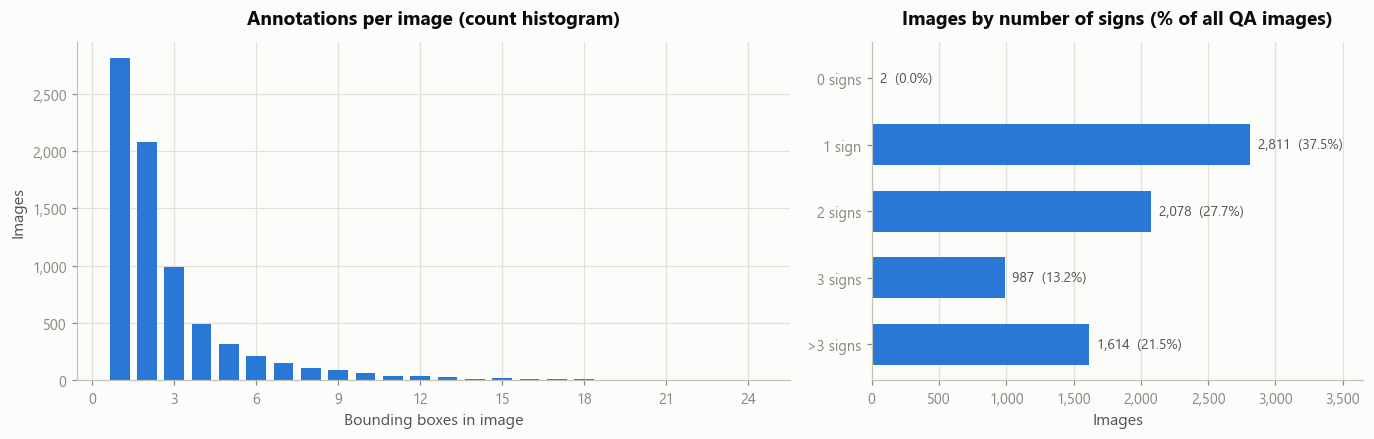

Annotated images      : 7,490
Images with no boxes  : 2
Boxes per image (all) : mean 2.74, median 2, std 2.56, min 0, max 24
Quartiles (all images): q25 1 | q75 3


In [19]:
per_image = qa_anns.groupby("image_uid").size()               # annotated images only
per_image_all = annlib.per_image_counts(qa_images, qa_anns)   # every QA image, 0 included
empty_images = int((per_image_all == 0).sum())

overview_ann = annlib.overview_table(qa_files, qa_images, qa_anns, qa_cats)
overview_ann.to_csv(config.CSV_DIR / "annotation_overview.csv", index=False)
display(overview_ann.style.hide(axis="index"))

buckets = annlib.sign_count_buckets(qa_images, qa_anns)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.1), gridspec_kw={"width_ratios": [1.45, 1]})
counts = per_image.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=plotstyle.ACCENT, width=0.72)
axes[0].set_title("Annotations per image (count histogram)")
axes[0].set_xlabel("Bounding boxes in image")
axes[0].set_ylabel("Images")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))

bucket_rows = buckets.iloc[::-1]
bars = axes[1].barh(bucket_rows.index.astype(str), bucket_rows["images"],
                    color=plotstyle.ACCENT, height=0.62)
for bar, (_, row) in zip(bars, bucket_rows.iterrows()):
    axes[1].annotate(f"{int(row['images']):,}  ({row['pct_of_all_images']:.1f}%)",
                     (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va="center", fontsize=9, color=plotstyle.INK_SECONDARY)
plotstyle.style_h_barh(axes[1])
axes[1].set_title("Images by number of signs (% of all QA images)")
axes[1].set_xlabel("Images")
axes[1].xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
axes[1].margins(x=0.30)
fig.tight_layout()
plotstyle.save_fig(fig, "fig13_annotations_per_image")
plt.show()

print(f"Annotated images      : {int((per_image_all > 0).sum()):,}")
print(f"Images with no boxes  : {empty_images:,}")
print(f"Boxes per image (all) : mean {per_image_all.mean():.2f}, median {per_image_all.median():.0f}, "
      f"std {per_image_all.std():.2f}, min {per_image_all.min()}, max {per_image_all.max()}")
print(f"Quartiles (all images): q25 {per_image_all.quantile(0.25):.0f} | q75 {per_image_all.quantile(0.75):.0f}")


### 7.2 Class distribution and imbalance

Class frequencies follow the long-tailed distribution typical of street-level object
datasets. The two *Unknown* classes (`Back-Unknown`, `Other-Unknown`) capture sign backs
and unclassifiable plates; the remaining classes are concrete Maltese sign types.

Two complementary units are reported for every class: **annotations** (bounding boxes)
and **unique images** containing at least one instance — a class can rank differently on
the two when its instances cluster in few captures. The complete per-class table (class
id, name, counts, percentages, image reach, rank — including the rarest classes, nothing
truncated) is exported to `class_distribution.csv`. Imbalance is quantified with the
max/min ratio, the Gini coefficient over class frequencies, head-of-distribution shares
(top 1/3/5/10), and the number of classes covering 80% and 90% of all annotations.
Because the label map holds only 12 classes, the ranked charts show *every* class — the
"top" and "least represented" ends are both fully visible rather than split into
separate truncated views.


rank,category_id,category_name,annotations,pct_of_annotations,images_with_class,pct_of_annotated_images
1,11,Back-Unknown,6727,32.760000,3703,49.440000
2,12,Other-Unknown,2342,11.400000,1680,22.430000
3,3,No Entry (One Way),2214,10.780000,1849,24.690000
4,6,Blind-Spot Mirror (Convex Mirror),1650,8.030000,1465,19.560000
5,1,Pedestrian Crossing,1457,7.090000,1140,15.220000
6,2,Stop Sign,1338,6.520000,1280,17.090000
7,10,Auxiliary Sign,1300,6.330000,993,13.260000
8,8,Directional Sign,1126,5.480000,773,10.320000
9,7,Street Sign,1009,4.910000,938,12.520000
10,4,Roundabout Ahead,803,3.910000,656,8.760000


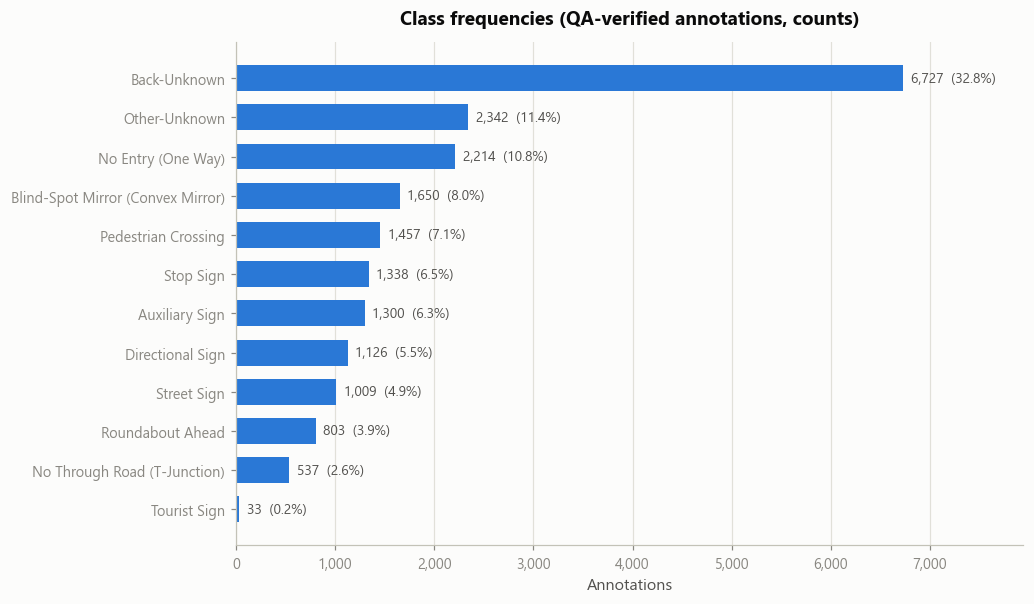

In [20]:
class_counts = qa_anns["category_name"].value_counts()
share = class_counts / class_counts.sum()

# Complete per-class table; class_frequencies.csv is kept as the legacy export
# referenced by the methodology writing notes.
class_table = annlib.class_distribution(qa_anns, qa_cats)
class_table.to_csv(config.CSV_DIR / "class_distribution.csv", index=False)
freq_table = pd.DataFrame({"annotations": class_counts,
                           "share_pct": (share * 100).round(2)})
freq_table.to_csv(config.CSV_DIR / "class_frequencies.csv")
display(class_table.style.hide(axis="index"))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
bars = ax.barh(class_counts.index[::-1], class_counts.values[::-1],
               color=plotstyle.ACCENT, height=0.66)
for bar, (name, count) in zip(ax.patches, list(class_counts.items())[::-1]):
    ax.annotate(f"{count:,}  ({share[name]:.1%})",
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=plotstyle.INK_SECONDARY)
plotstyle.style_h_barh(ax)
ax.set_title("Class frequencies (QA-verified annotations, counts)")
ax.set_xlabel("Annotations")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.18)
fig.tight_layout()
plotstyle.save_fig(fig, "fig14_class_frequencies")
plt.show()


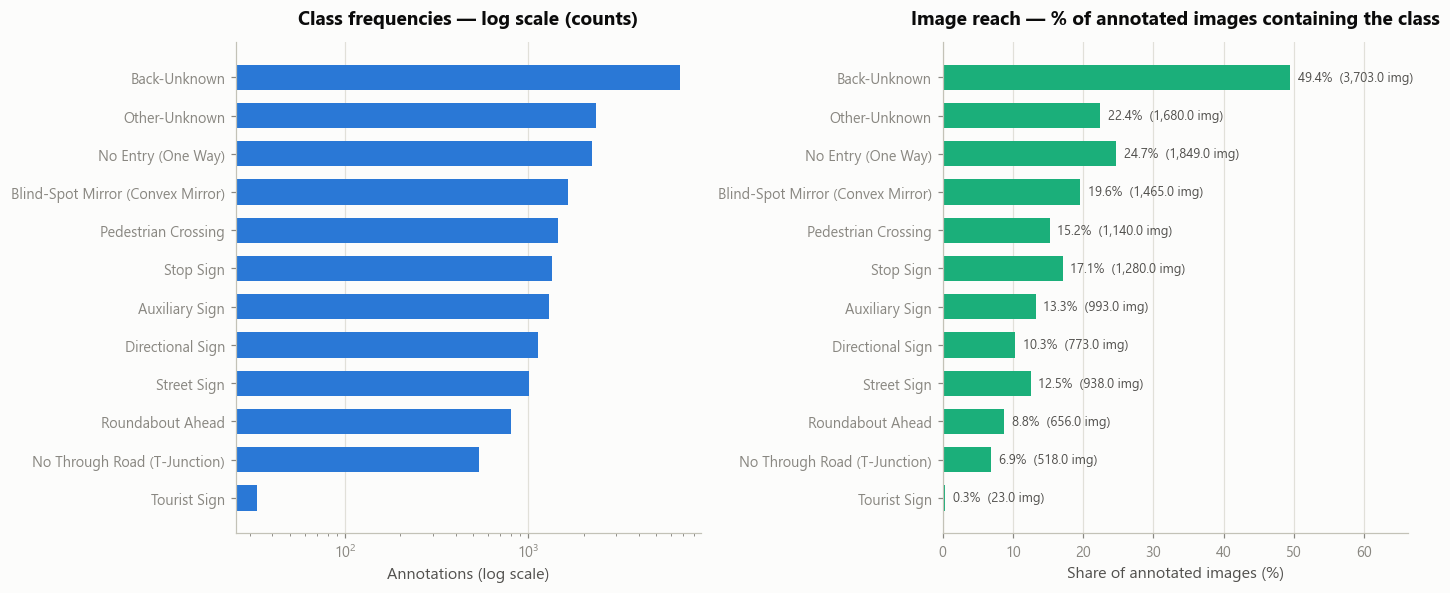

Most represented : Back-Unknown — 6,727 annotations (32.8%) in 3,703 images
Least represented: Tourist Sign — 33 annotations (0.16%) in 23 images


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.5))

# A log axis keeps the tail readable: on a linear axis every class under ~1k
# boxes collapses into indistinguishable slivers.
axes[0].barh(class_counts.index[::-1], class_counts.values[::-1],
             color=plotstyle.ACCENT, height=0.66)
axes[0].set_xscale("log")
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Class frequencies — log scale (counts)")
axes[0].set_xlabel("Annotations (log scale)")

reach = class_table.set_index("category_name").loc[class_counts.index]
bars = axes[1].barh(reach.index[::-1], reach["pct_of_annotated_images"][::-1],
                    color=plotstyle.CATEGORICAL[1], height=0.66)
for bar, (name, row) in zip(bars, reach[::-1].iterrows()):
    axes[1].annotate(f"{row['pct_of_annotated_images']:.1f}%  ({row['images_with_class']:,} img)",
                     (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va="center", fontsize=8.5, color=plotstyle.INK_SECONDARY)
plotstyle.style_h_barh(axes[1])
axes[1].set_title("Image reach — % of annotated images containing the class")
axes[1].set_xlabel("Share of annotated images (%)")
axes[1].margins(x=0.34)
fig.tight_layout()
plotstyle.save_fig(fig, "fig22_class_log_and_image_reach")
plt.show()

head, tail = class_table.iloc[0], class_table.iloc[-1]
print(f"Most represented : {head['category_name']} — {head['annotations']:,} annotations "
      f"({head['pct_of_annotations']:.1f}%) in {head['images_with_class']:,} images")
print(f"Least represented: {tail['category_name']} — {tail['annotations']:,} annotations "
      f"({tail['pct_of_annotations']:.2f}%) in {tail['images_with_class']:,} images")


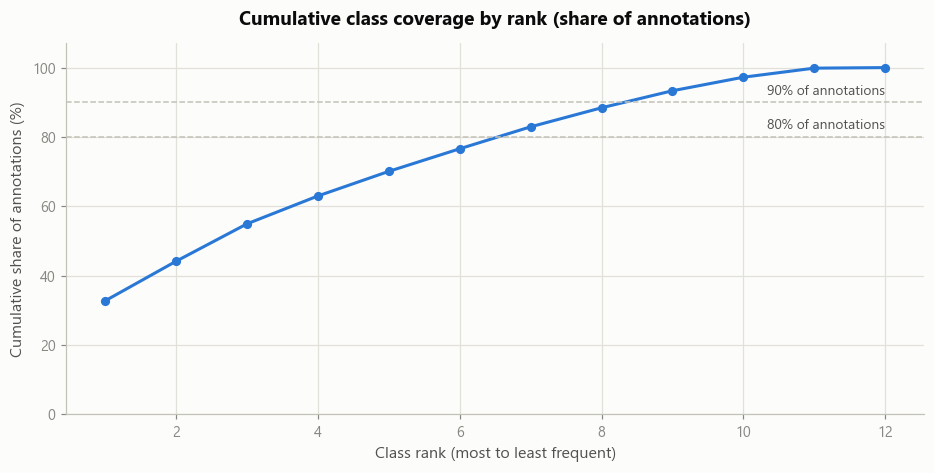

- **Imbalance ratio** (most/least frequent): **204 : 1**
- **Gini coefficient** over class frequencies: **0.42**
- Share of annotations held by the top classes: top 1 = **32.8%**, top 3 = 54.9%, top 5 = 70.1%, top 10 = 97.2%
- **7 of 12 classes** cover 80% of annotations; **9** cover 90%

In [22]:
imbalance = coco.class_imbalance_metrics(qa_anns)
pd.Series(imbalance).rename("value").rename_axis("metric").to_csv(
    config.CSV_DIR / "class_imbalance_metrics.csv")
cumulative = share.cumsum().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, color=plotstyle.ACCENT,
        linewidth=2, marker="o", markersize=5)
for level in (80, 90):
    ax.axhline(level, color=plotstyle.BASELINE, linewidth=1, linestyle="--")
    ax.annotate(f"{level}% of annotations", xy=(len(cumulative), level), xytext=(0, 5),
                textcoords="offset points", ha="right", fontsize=9,
                color=plotstyle.INK_SECONDARY)
ax.set_title("Cumulative class coverage by rank (share of annotations)")
ax.set_xlabel("Class rank (most to least frequent)")
ax.set_ylabel("Cumulative share of annotations (%)")
ax.set_ylim(0, 107)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout()
plotstyle.save_fig(fig, "fig15_class_longtail")
plt.show()

display(Markdown(
    f"- **Imbalance ratio** (most/least frequent): **{imbalance['imbalance_ratio']:.0f} : 1**\n"
    f"- **Gini coefficient** over class frequencies: **{imbalance['gini_coefficient']:.2f}**\n"
    f"- Share of annotations held by the top classes: "
    f"top 1 = **{imbalance['top1_share_pct']:.1f}%**, "
    f"top 3 = {imbalance['top3_share_pct']:.1f}%, "
    f"top 5 = {imbalance['top5_share_pct']:.1f}%, "
    f"top 10 = {imbalance['top10_share_pct']:.1f}%\n"
    f"- **{imbalance['classes_for_80pct']} of {imbalance['num_classes']} classes** cover 80% "
    f"of annotations; **{imbalance['classes_for_90pct']}** cover 90%"
))


### 7.3 Bounding-box geometry

Box geometry is analysed in **image-relative coordinates** wherever possible, because the
corpus mixes resolutions — a 200 px box means something different in a 12 MP and a 48 MP
capture. The COCO small/medium/large convention (absolute-pixel thresholds at 32² and 96²)
is also reported since it drives evaluation protocols such as AP_S/AP_M/AP_L. Unit:
annotations throughout. Beyond the corpus-level views, per-class geometry is exported to
`bbox_summary_by_class.csv`, and the size mix is broken down per class, per condition, and
per view angle — small distant signs and close-up damaged signs stress detectors very
differently.


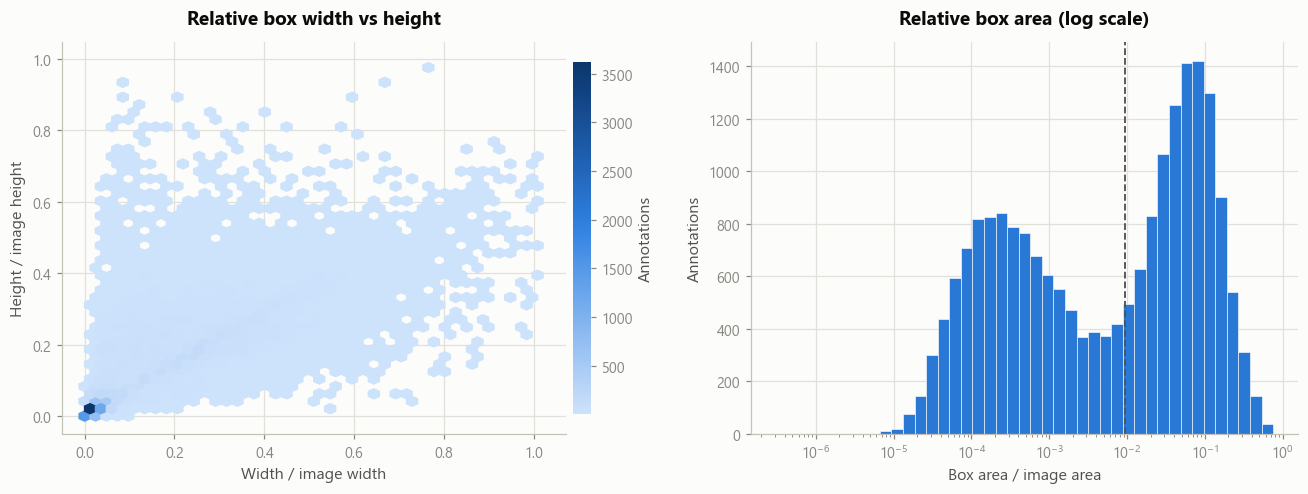

Median relative area : 0.9382% of the image
Median box (px)      : 206 x 338
Box aspect (w/h)     : median 0.91, IQR 0.56-1.08


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})

hexes = axes[0].hexbin(qa_anns["rel_width"], qa_anns["rel_height"], gridsize=42,
                       cmap=plotstyle.BLUES_CMAP, mincnt=1,
                       extent=(0, qa_anns["rel_width"].max() * 1.02,
                               0, qa_anns["rel_height"].max() * 1.02))
axes[0].set_title("Relative box width vs height")
axes[0].set_xlabel("Width / image width")
axes[0].set_ylabel("Height / image height")
cbar = fig.colorbar(hexes, ax=axes[0], shrink=0.9, pad=0.012)
cbar.set_label("Annotations", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)

positive_area = qa_anns.loc[qa_anns["rel_area"] > 0, "rel_area"]
area_bins = np.geomspace(positive_area.min(), positive_area.max(), 44)
axes[1].hist(positive_area, bins=area_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[1].set_xscale("log")
axes[1].axvline(qa_anns["rel_area"].median(), color=plotstyle.INK_SECONDARY,
                linewidth=1.2, linestyle="--")
axes[1].set_title("Relative box area (log scale)")
axes[1].set_xlabel("Box area / image area")
axes[1].set_ylabel("Annotations")

fig.tight_layout()
plotstyle.save_fig(fig, "fig16_bbox_geometry")
plt.show()

print(f"Median relative area : {qa_anns['rel_area'].median():.4%} of the image")
print(f"Median box (px)      : {qa_anns['bbox_w'].median():.0f} x {qa_anns['bbox_h'].median():.0f}")
print(f"Box aspect (w/h)     : median {qa_anns['bbox_aspect'].median():.2f}, "
      f"IQR {qa_anns['bbox_aspect'].quantile(0.25):.2f}-{qa_anns['bbox_aspect'].quantile(0.75):.2f}")


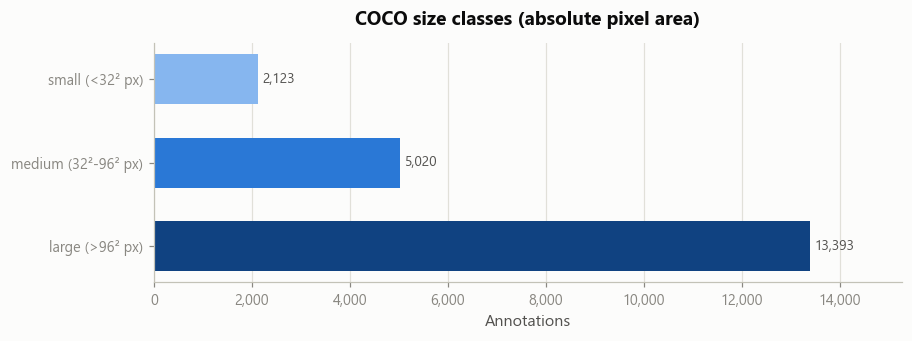

Small-object share (COCO <32² px): 10.3%


In [24]:
# Ordered size classes wear an ordinal one-hue ramp (light -> dark = small -> large).
ORDINAL_3 = ["#86b6ef", "#2a78d6", "#104281"]
size_counts = qa_anns["size_class"].value_counts().reindex(
    ["small (<32² px)", "medium (32²-96² px)", "large (>96² px)"])

fig, ax = plt.subplots(figsize=(8.4, 3.2))
bars = ax.barh(size_counts.index[::-1], size_counts.values[::-1],
               color=ORDINAL_3[::-1], height=0.6)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title("COCO size classes (absolute pixel area)")
ax.set_xlabel("Annotations")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.14)
fig.tight_layout()
plotstyle.save_fig(fig, "fig17_coco_size_classes")
plt.show()

print(f"Small-object share (COCO <32² px): {size_counts.iloc[0] / size_counts.sum():.1%}")


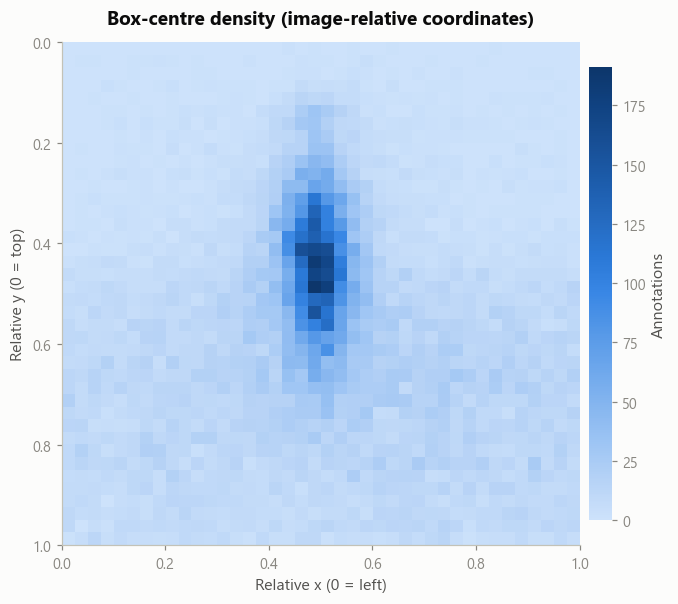

Box centres in the central third of the frame: 42.5% - a strong centring prior, consistent with deliberate, sign-focused capture rather than dashcam footage.


In [25]:
heat, xedges, yedges = np.histogram2d(qa_anns["rel_cx"], qa_anns["rel_cy"],
                                      bins=40, range=[[0, 1], [0, 1]])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
mesh = ax.imshow(heat.T, origin="upper", extent=(0, 1, 1, 0),
                 cmap=plotstyle.BLUES_CMAP, aspect="auto")
ax.set_title("Box-centre density (image-relative coordinates)")
ax.set_xlabel("Relative x (0 = left)")
ax.set_ylabel("Relative y (0 = top)")
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9, pad=0.015)
cbar.set_label("Annotations", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)
fig.tight_layout()
plotstyle.save_fig(fig, "fig18_box_centre_density")
plt.show()

central = ((qa_anns["rel_cx"].between(1/3, 2/3)) & (qa_anns["rel_cy"].between(1/3, 2/3))).mean()
print(f"Box centres in the central third of the frame: {central:.1%} - a strong centring "
      f"prior, consistent with deliberate, sign-focused capture rather than dashcam footage.")


category_name,annotations,median_bbox_w_px,median_bbox_h_px,median_aspect_w_h,median_rel_width,median_rel_height,median_rel_area_pct,mean_rel_area_pct,pct_small,pct_medium,pct_large
Back-Unknown,6727,202.600000,320.000000,0.954000,0.081300,0.091100,0.867500,4.985600,9.140000,26.400000,64.460000
Other-Unknown,2342,95.100000,140.500000,0.912000,0.034200,0.036700,0.127800,2.690000,13.960000,31.170000,54.870000
No Entry (One Way),2214,351.100000,654.300000,0.870000,0.127700,0.170800,2.517200,5.065800,10.750000,17.340000,71.910000
Blind-Spot Mirror (Convex Mirror),1650,475.600000,758.100000,0.783000,0.186400,0.201900,3.890700,6.986000,4.420000,13.210000,82.360000
Pedestrian Crossing,1457,230.300000,405.800000,0.926000,0.092500,0.119100,1.245400,5.247200,11.120000,24.910000,63.970000
Stop Sign,1338,500.100000,827.600000,0.863000,0.181800,0.206400,3.771300,6.315500,5.980000,9.790000,84.230000
Auxiliary Sign,1300,85.900000,90.900000,1.081000,0.029900,0.023900,0.068400,1.843400,18.770000,34.380000,46.850000
Directional Sign,1126,59.800000,97.000000,0.656000,0.021600,0.025600,0.052900,1.003500,15.720000,43.250000,41.030000
Street Sign,1009,158.500000,147.300000,1.259000,0.055100,0.045600,0.256900,1.362900,12.190000,26.960000,60.850000
Roundabout Ahead,803,372.400000,585.500000,0.912000,0.164700,0.165700,3.073700,6.131200,9.460000,19.930000,70.610000


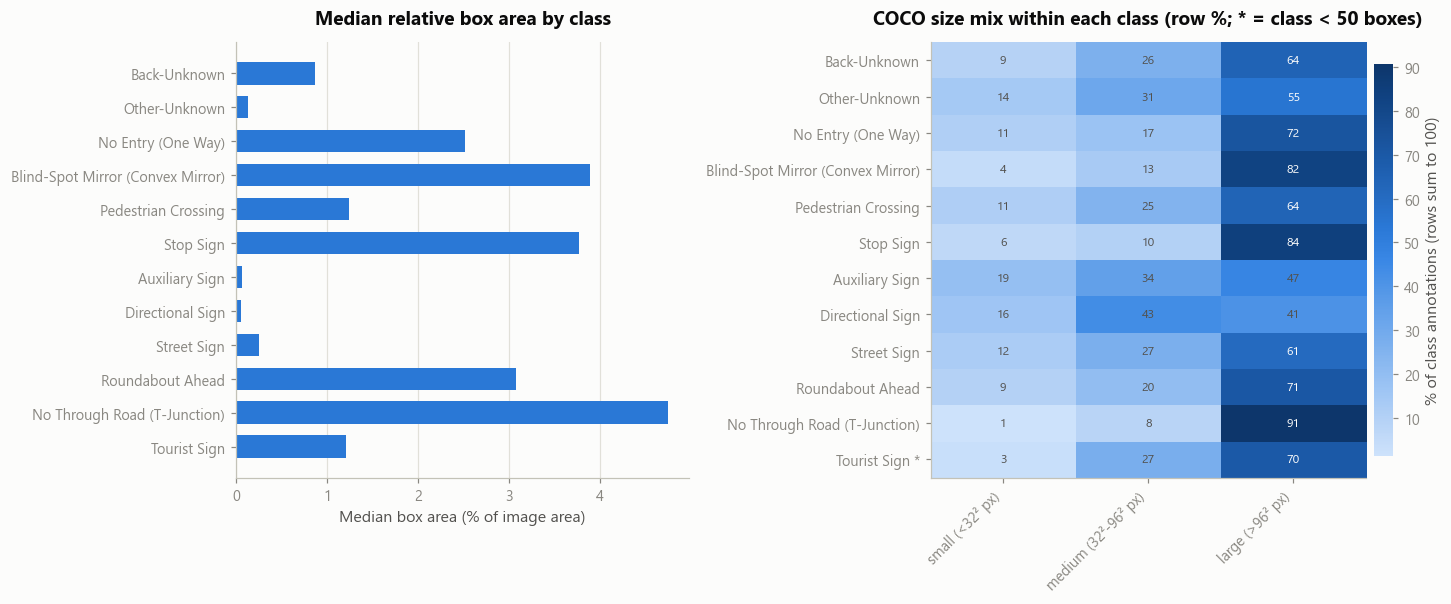

In [26]:
bbox_by_class = annlib.bbox_summary(qa_anns, by="category_name")
bbox_by_class.to_csv(config.CSV_DIR / "bbox_summary_by_class.csv", index=False)
display(bbox_by_class.style.hide(axis="index"))

size_ct = annlib.crosstab_matrices(qa_anns, "category_name", "size_class")
size_ct["counts"].to_csv(config.CSV_DIR / "class_size_class_counts.csv")
size_ct["row_pct"].to_csv(config.CSV_DIR / "class_size_class_row_percentages.csv")

low_flags = (class_table.set_index("category_name")["annotations"] < MIN_CLASS_SAMPLE)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.6), gridspec_kw={"width_ratios": [1, 1.15]})
med = bbox_by_class.set_index("category_name")["median_rel_area_pct"]
axes[0].barh(med.index[::-1], med.values[::-1], color=plotstyle.ACCENT, height=0.66)
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Median relative box area by class")
axes[0].set_xlabel("Median box area (% of image area)")

plotstyle.heatmap(axes[1], size_ct["row_pct"], fmt="{:.0f}", hide_zeros=False,
                  cbar_label="% of class annotations (rows sum to 100)",
                  row_flags=low_flags.reindex(size_ct["row_pct"].index))
axes[1].set_title(f"COCO size mix within each class (row %; * = class < {MIN_CLASS_SAMPLE} boxes)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig23_bbox_by_class")
plt.show()


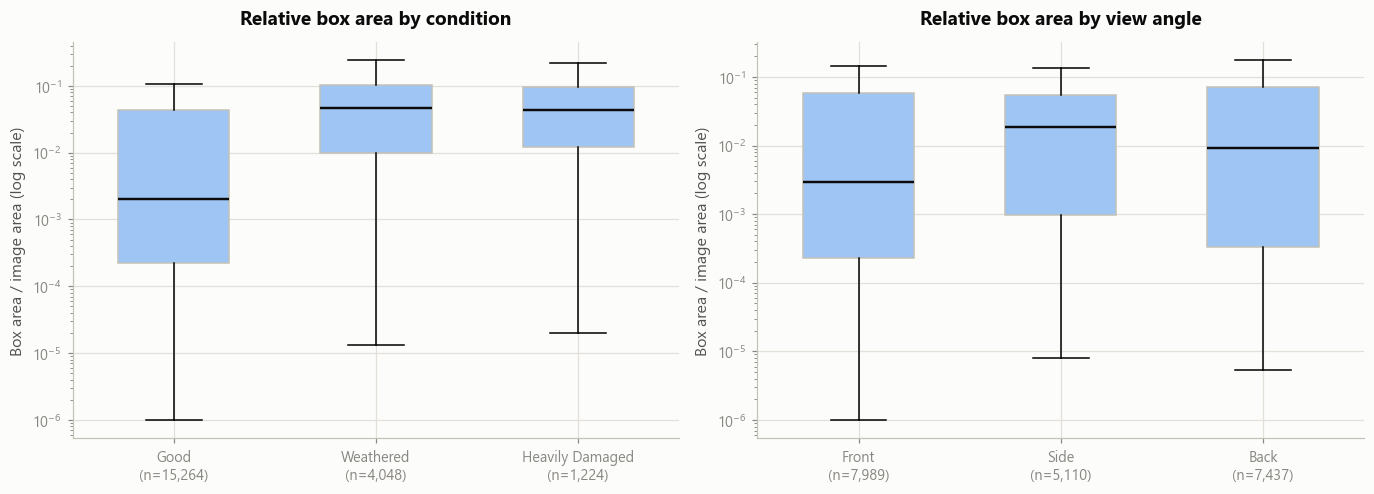

condition,annotations,median_bbox_w_px,median_bbox_h_px,median_aspect_w_h,median_rel_width,median_rel_height,median_rel_area_pct,mean_rel_area_pct,pct_small,pct_medium,pct_large
Good,15264,119.800000,175.300000,0.906000,0.044100,0.047600,0.201000,3.558300,12.960000,29.320000,57.720000
Weathered,4048,620.200000,809.800000,0.947000,0.227100,0.205900,4.654600,7.385700,2.920000,10.300000,86.780000
Heavily Damaged,1224,532.200000,793.800000,0.887000,0.202600,0.204900,4.351500,6.804700,2.210000,10.380000,87.420000


view_angle,annotations,median_bbox_w_px,median_bbox_h_px,median_aspect_w_h,median_rel_width,median_rel_height,median_rel_area_pct,mean_rel_area_pct,pct_small,pct_medium,pct_large
Front,7989,163.300000,168.800000,1.017000,0.062500,0.047700,0.290800,4.333800,13.480000,26.900000,59.620000
Side,5110,235.900000,688.800000,0.457000,0.089900,0.185800,1.855000,3.990000,7.380000,17.630000,74.990000
Back,7437,209.700000,326.400000,0.937000,0.086300,0.095200,0.915500,5.046100,9.000000,26.490000,64.520000


Weathered and heavily damaged signs occupy markedly larger boxes than good ones - damaged signage was deliberately photographed close-up, so condition and object scale are confounded in this corpus (relevant when stratifying detector metrics).


In [27]:
bbox_by_condition = annlib.bbox_summary(qa_anns, by="condition")
bbox_by_view = annlib.bbox_summary(qa_anns, by="view_angle")
bbox_by_condition.to_csv(config.CSV_DIR / "bbox_summary_by_condition.csv", index=False)
bbox_by_view.to_csv(config.CSV_DIR / "bbox_summary_by_view_angle.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for ax, column, title in ((axes[0], "condition", "condition"),
                          (axes[1], "view_angle", "view angle")):
    order = annlib.ordered_values(qa_anns, column)
    data = [qa_anns.loc[qa_anns[column] == value, "rel_area"].clip(lower=1e-6)
            for value in order]
    boxes = ax.boxplot(data, tick_labels=[f"{v}\n(n={len(d):,})" for v, d in zip(order, data)],
                       showfliers=False, patch_artist=True, widths=0.55)
    for patch in boxes["boxes"]:
        patch.set(facecolor=plotstyle.SEQUENTIAL_BLUES[2], edgecolor=plotstyle.BASELINE)
    for line in boxes["medians"]:
        line.set(color=plotstyle.INK, linewidth=1.6)
    ax.set_yscale("log")
    ax.set_title(f"Relative box area by {title}")
    ax.set_ylabel("Box area / image area (log scale)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig24_bbox_by_condition_view")
plt.show()

display(bbox_by_condition.style.hide(axis="index"))
display(bbox_by_view.style.hide(axis="index"))
print("Weathered and heavily damaged signs occupy markedly larger boxes than good ones - "
      "damaged signage was deliberately photographed close-up, so condition and object "
      "scale are confounded in this corpus (relevant when stratifying detector metrics).")


### 7.4 Class co-occurrence

The matrix counts images in which two classes appear together (diagonal = images containing
the class at all). Co-occurrence structure matters for sampling strategy: classes that only
appear alongside dominant ones cannot be isolated by naive image-level resampling.


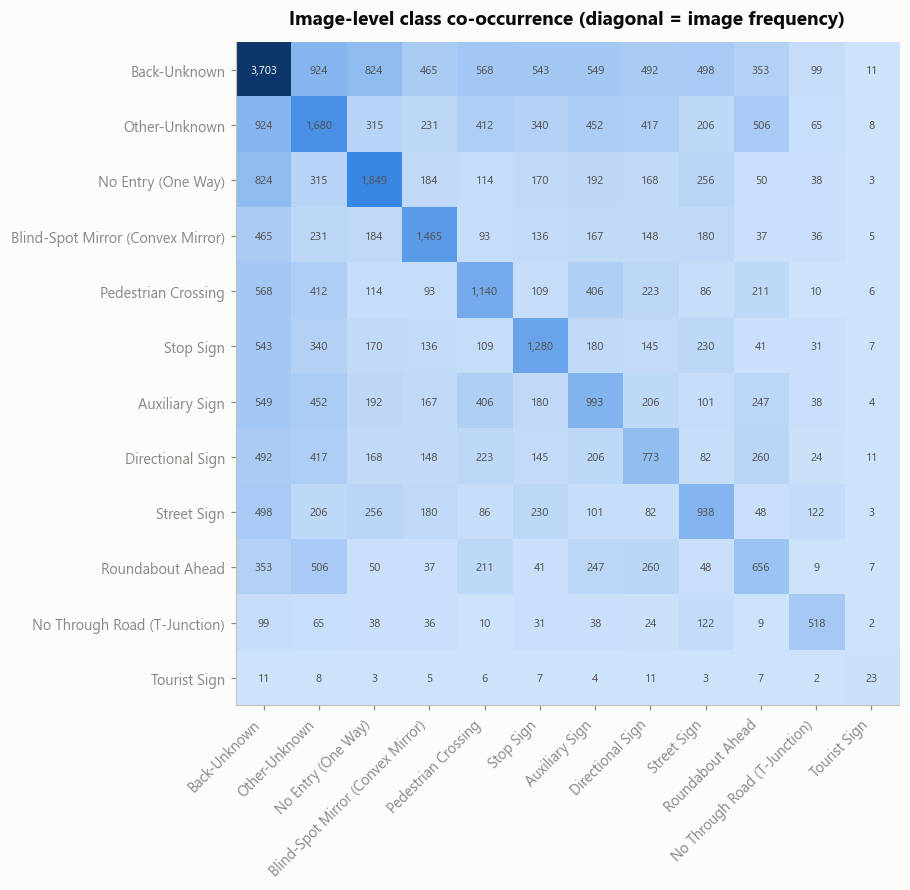

In [28]:
presence = (qa_anns.assign(present=1)
            .pivot_table(index="image_uid", columns="category_name",
                         values="present", aggfunc="max", fill_value=0))
order = class_counts.index.tolist()
present_ordered = presence[order]
cooc = present_ordered.T @ present_ordered

fig, ax = plt.subplots(figsize=(9.6, 8.2))
mesh = ax.imshow(cooc.values, cmap=plotstyle.BLUES_CMAP)
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.grid(False)
threshold = cooc.values.max() * 0.55
for i in range(len(order)):
    for j in range(len(order)):
        value = int(cooc.values[i, j])
        if value:
            ax.text(j, i, f"{value:,}", ha="center", va="center", fontsize=7.5,
                    color=plotstyle.SURFACE if value > threshold else plotstyle.INK_SECONDARY)
ax.set_title("Image-level class co-occurrence (diagonal = image frequency)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig19_class_cooccurrence")
plt.show()

cooc.to_csv(config.CSV_DIR / "class_cooccurrence.csv")


### 7.5 Auxiliary attribute distributions

Every QA-verified box carries four auxiliary attributes (*view angle*, *mounting*,
*condition*, *sign shape*) plus an `origin` provenance flag. These enable stratified
evaluation (e.g. detection quality on weathered vs pristine signs) and provide a
physical-condition census of Maltese signage as a by-product of the dataset.

Each attribute is analysed independently. For every **discovered** value the tables report
the annotation count and percentage, the number of unique images, and the number of
classes in which the value occurs; missing keys, explicit nulls, and fallback values
(e.g. `Damaged-Unknown`) are reported as their own rows rather than silently dropped.
One CSV per attribute is exported (`attribute_distribution_<attribute>.csv`);
`attribute_summary.csv` is kept as the legacy compact export. Unit: annotations
(image counts are given alongside, never mixed).


attribute,value,value_kind,annotations,pct_of_annotations,images,pct_of_annotated_images,classes
view_angle,Front,regular,7989,38.900000,4121,55.020000,12
view_angle,Side,regular,5110,24.880000,3651,48.740000,12
view_angle,Back,regular,7437,36.210000,4021,53.680000,7
view_angle,(null value),null,0,0.000000,0,0.000000,0
view_angle,(attribute absent),missing,0,0.000000,0,0.000000,0
mounting,Pole-Mounted,regular,17815,86.750000,6711,89.600000,12
mounting,Wall-Mounted,regular,2721,13.250000,1798,24.010000,12
mounting,(null value),null,0,0.000000,0,0.000000,0
mounting,(attribute absent),missing,0,0.000000,0,0.000000,0
condition,Good,regular,15264,74.330000,5886,78.580000,12


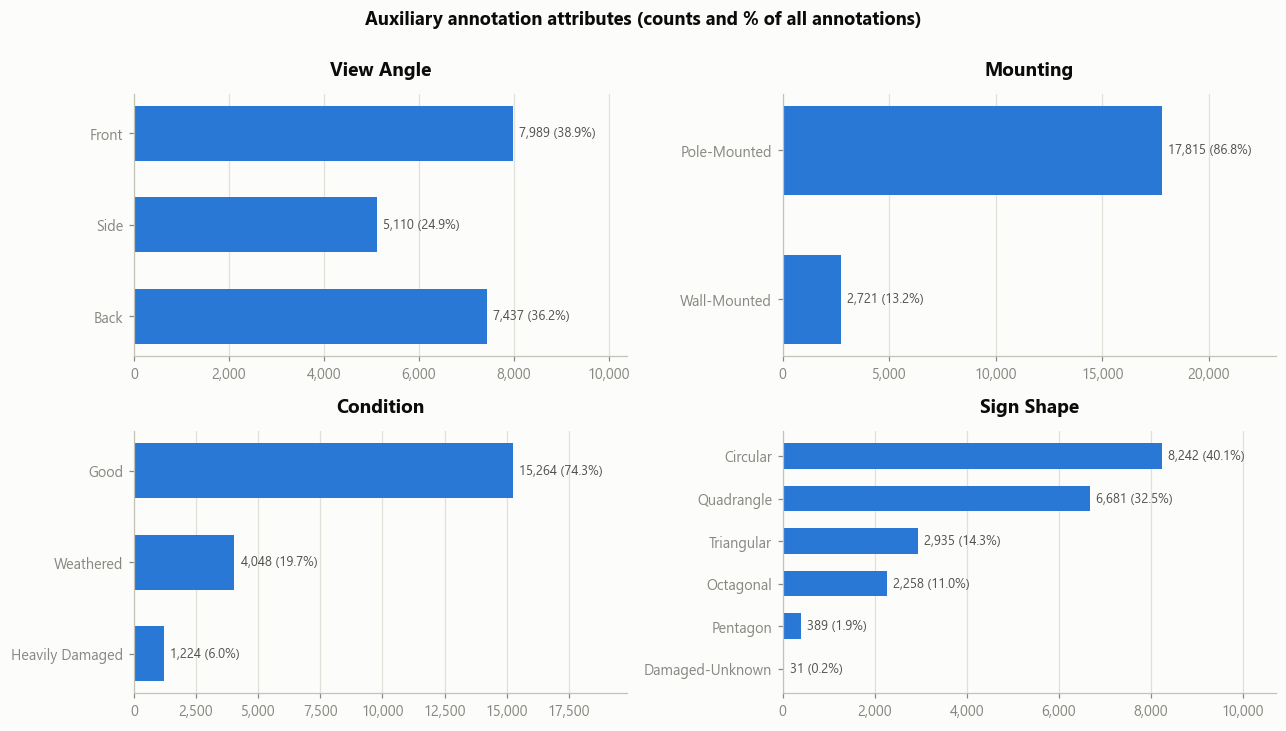

origin values: {'manual': np.int64(20536)} - annotation provenance, not a sign property. With 1 distinct value(s) it is excluded from the co-occurrence analyses below (a single-valued attribute carries no relational information).


In [29]:
attr_tables = {}
for column in coco.ATTRIBUTE_KEYS:   # view_angle, mounting, condition, sign_shape, origin
    table = annlib.attribute_distribution(qa_anns, column)
    attr_tables[column] = table
    table.to_csv(config.CSV_DIR / f"attribute_distribution_{column}.csv", index=False)
display(pd.concat(attr_tables.values(), ignore_index=True).style.hide(axis="index"))

# Legacy compact export (referenced by the methodology writing notes).
attr_summary = pd.concat({column: qa_anns[column].value_counts()
                          for column in coco.ATTRIBUTE_KEYS[:4]}, names=["attribute", "value"])
attr_summary.rename("annotations").to_csv(config.CSV_DIR / "attribute_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(11.8, 6.6))
total = len(qa_anns)
for ax, column in zip(axes.flat, coco.ATTRIBUTE_KEYS[:4]):
    counts = qa_anns[column].value_counts().reindex(annlib.ordered_values(qa_anns, column))
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=plotstyle.ACCENT, height=0.6)
    for bar, value in zip(bars, counts.values[::-1]):
        ax.annotate(f"{value:,} ({value / total:.1%})",
                    (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=plotstyle.INK_SECONDARY)
    plotstyle.style_h_barh(ax)
    ax.set_title(column.replace("_", " ").title())
    ax.margins(x=0.30)
    ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.suptitle("Auxiliary annotation attributes (counts and % of all annotations)",
             fontweight="bold", y=1.0)
fig.tight_layout()
plotstyle.save_fig(fig, "fig20_auxiliary_attributes")
plt.show()

origin_counts = qa_anns["origin"].value_counts()
print(f"origin values: {dict(origin_counts)} - annotation provenance, not a sign property. "
      f"With {origin_counts.size} distinct value(s) it is excluded from the co-occurrence "
      f"analyses below (a single-valued attribute carries no relational information).")


### 7.6 Class × attribute co-occurrence

For each auxiliary attribute, three matrices relate it to the traffic-sign class
(unit: annotations):

1. **raw counts** — how many boxes of class *c* carry attribute value *v*;
2. **row-normalised** (% within each class, rows sum to 100) — the attribute profile of a
   class, comparable across classes of different size;
3. **column-normalised** (% within each attribute value, columns sum to 100) — which
   classes make up e.g. the *Heavily Damaged* pool.

All three are exported per attribute (`class_<attribute>_counts.csv`,
`..._row_percentages.csv`, `..._column_percentages.csv`) with **every class included** —
rare classes are never dropped. In the heatmaps, classes with fewer than
`MIN_CLASS_SAMPLE` annotations are flagged with `*`: their percentage rows rest on very
few examples and should not be over-interpreted. With 12 classes the complete heatmap is
practical, so no separate top-classes view is needed. `origin` is skipped here because it
currently holds a single value (§7.5).


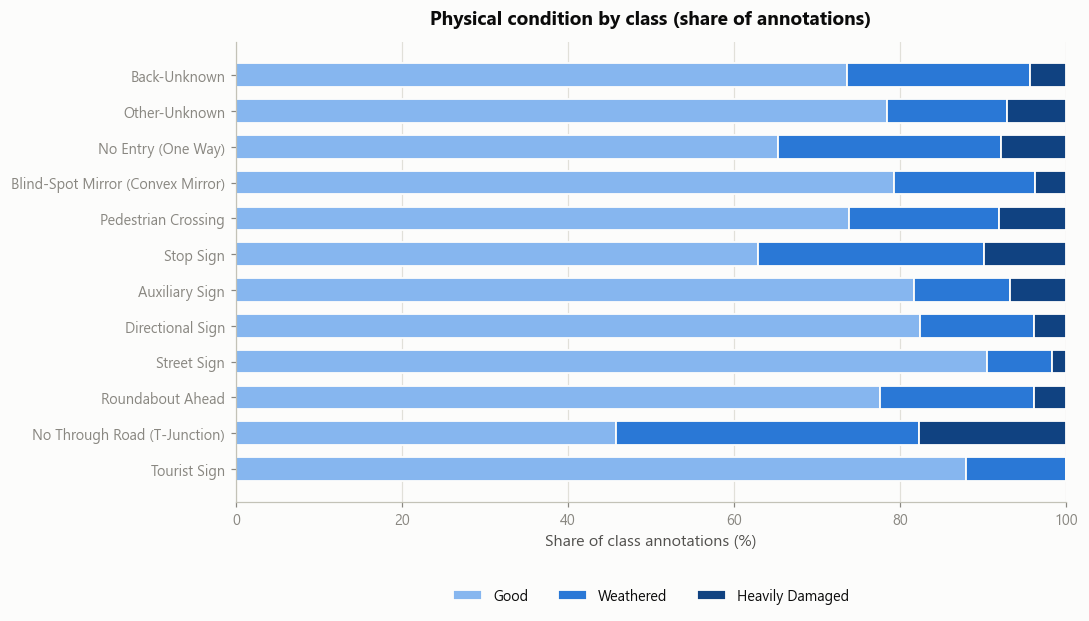

Signs not in good condition: 25.7% of all annotations


In [30]:
# Condition severity is ordered -> ordinal one-hue ramp (light = good, dark = damaged).
condition_order = ["Good", "Weathered", "Heavily Damaged"]
by_class = (qa_anns.dropna(subset=["condition"])
            .pivot_table(index="category_name", columns="condition",
                         values="annotation_uid", aggfunc="size", fill_value=0)
            .reindex(columns=condition_order)
            .reindex(class_counts.index))
shares = by_class.div(by_class.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 5.8))
left = np.zeros(len(shares))
for column, colour in zip(condition_order, ORDINAL_3):
    values = shares[column].values * 100
    ax.barh(shares.index[::-1], values[::-1], left=left[::-1], color=colour,
            height=0.66, label=column, edgecolor=plotstyle.SURFACE, linewidth=1.2)
    left += values
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=3, frameon=False)
plotstyle.style_h_barh(ax)
ax.set_title("Physical condition by class (share of annotations)")
ax.set_xlabel("Share of class annotations (%)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig21_condition_by_class")
plt.show()

weathered_share = (qa_anns["condition"] != "Good").mean()
print(f"Signs not in good condition: {weathered_share:.1%} of all annotations")


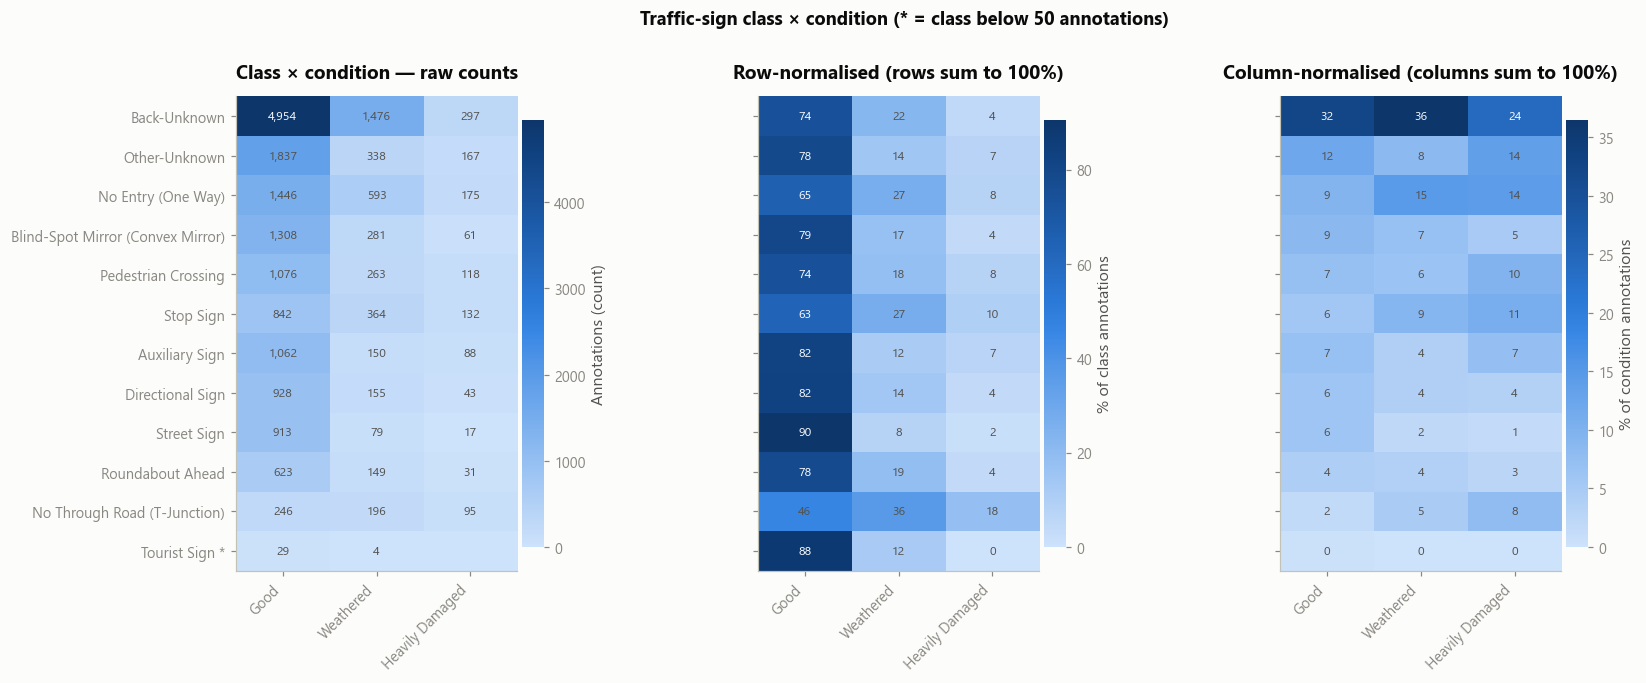

In [31]:
low_flags = (class_table.set_index("category_name")["annotations"] < MIN_CLASS_SAMPLE)

cc = annlib.crosstab_matrices(qa_anns, "category_name", "condition")
cc["counts"].to_csv(config.CSV_DIR / "class_condition_counts.csv")
cc["row_pct"].to_csv(config.CSV_DIR / "class_condition_row_percentages.csv")
cc["col_pct"].to_csv(config.CSV_DIR / "class_condition_column_percentages.csv")
if cc["excluded_nulls"]:
    print(f"Excluded {cc['excluded_nulls']:,} annotations with a null class or condition.")

flags = low_flags.reindex(cc["counts"].index)
fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.6), gridspec_kw={"wspace": 0.55})
plotstyle.heatmap(axes[0], cc["counts"], fmt="{:,.0f}", cbar_label="Annotations (count)",
                  row_flags=flags)
axes[0].set_title("Class × condition — raw counts")
plotstyle.heatmap(axes[1], cc["row_pct"], fmt="{:.0f}", hide_zeros=False,
                  cbar_label="% of class annotations", row_flags=flags)
axes[1].set_title("Row-normalised (rows sum to 100%)")
plotstyle.heatmap(axes[2], cc["col_pct"], fmt="{:.0f}", hide_zeros=False,
                  cbar_label="% of condition annotations", row_flags=flags)
axes[2].set_title("Column-normalised (columns sum to 100%)")
for ax in axes[1:]:                      # rows repeat panel 1 - drop the labels
    ax.set_yticklabels([])
fig.suptitle(f"Traffic-sign class × condition (* = class below {MIN_CLASS_SAMPLE} annotations)",
             fontweight="bold", y=1.02)
plotstyle.save_fig(fig, "fig25_class_condition_heatmaps")
plt.show()


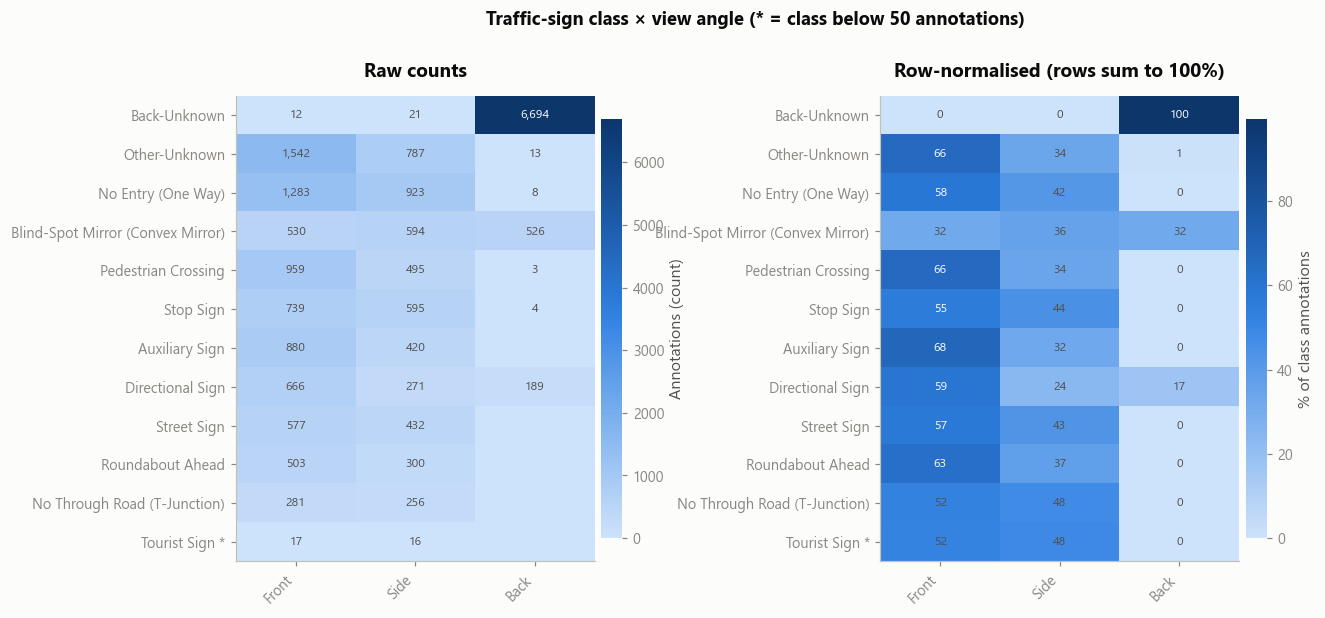

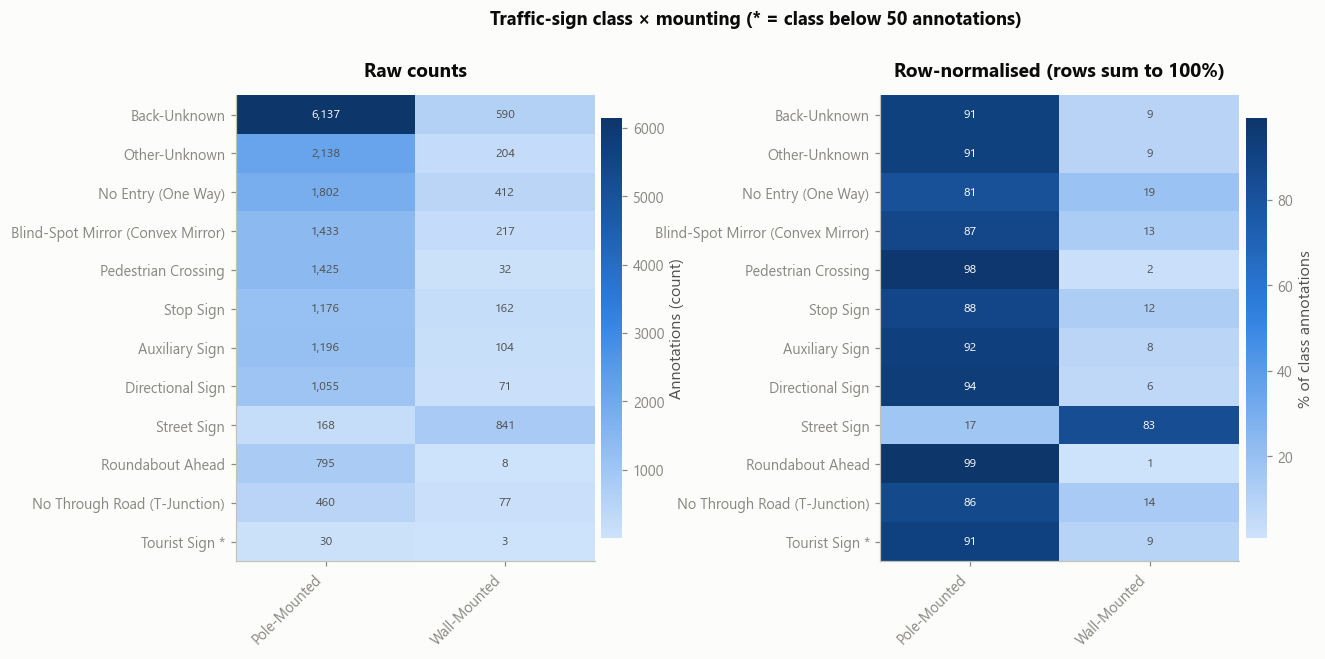

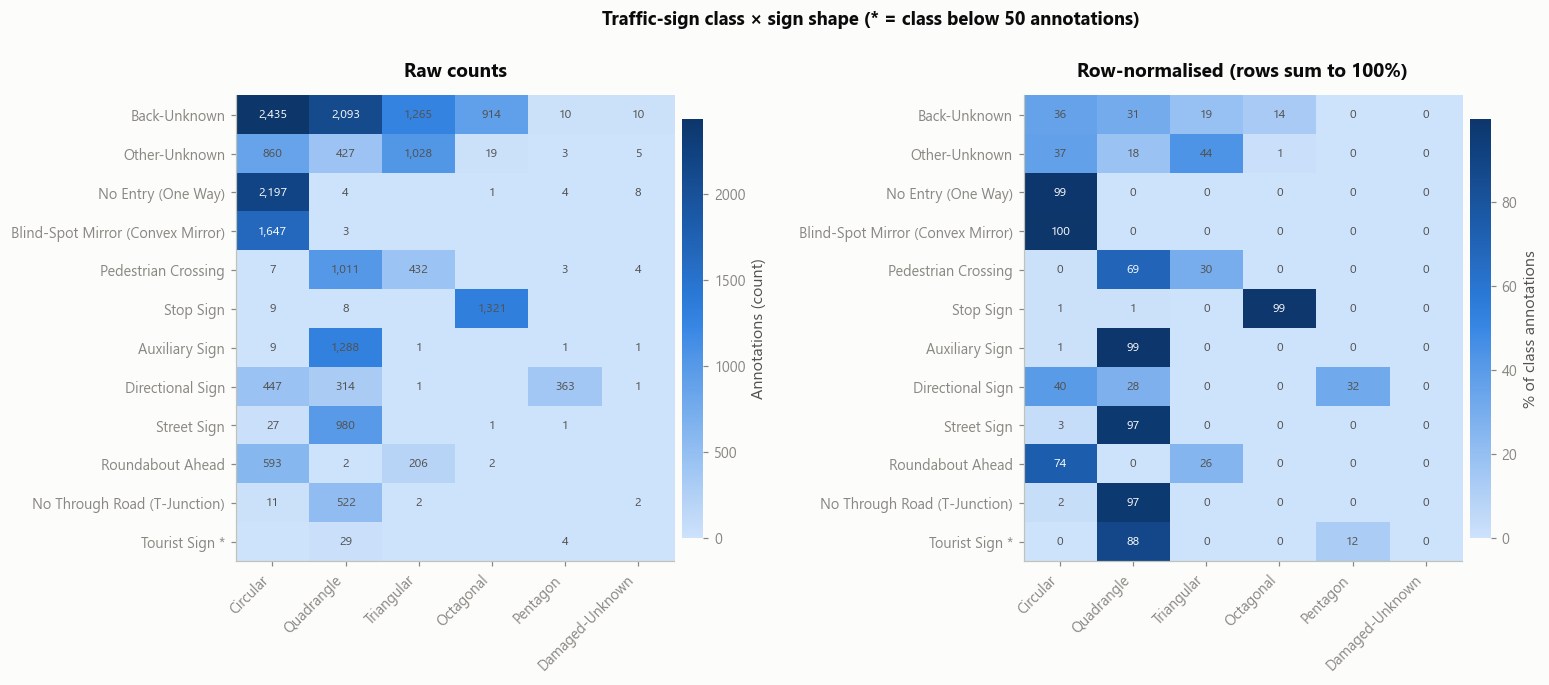

In [32]:
for fig_num, column in ((26, "view_angle"), (27, "mounting"), (28, "sign_shape")):
    ct = annlib.crosstab_matrices(qa_anns, "category_name", column)
    ct["counts"].to_csv(config.CSV_DIR / f"class_{column}_counts.csv")
    ct["row_pct"].to_csv(config.CSV_DIR / f"class_{column}_row_percentages.csv")
    ct["col_pct"].to_csv(config.CSV_DIR / f"class_{column}_column_percentages.csv")
    if ct["excluded_nulls"]:
        print(f"[{column}] excluded {ct['excluded_nulls']:,} annotations with nulls.")

    flags = low_flags.reindex(ct["counts"].index)
    width = 12.6 if len(ct["counts"].columns) <= 3 else 15.4
    fig, axes = plt.subplots(1, 2, figsize=(width, 5.5), gridspec_kw={"wspace": 0.5})
    plotstyle.heatmap(axes[0], ct["counts"], fmt="{:,.0f}",
                      cbar_label="Annotations (count)", row_flags=flags)
    axes[0].set_title("Raw counts")
    plotstyle.heatmap(axes[1], ct["row_pct"], fmt="{:.0f}", hide_zeros=False,
                      cbar_label="% of class annotations", row_flags=flags)
    axes[1].set_title("Row-normalised (rows sum to 100%)")
    label = column.replace("_", " ")
    fig.suptitle(f"Traffic-sign class × {label} "
                 f"(* = class below {MIN_CLASS_SAMPLE} annotations)",
                 fontweight="bold", y=1.02)
    plotstyle.save_fig(fig, f"fig{fig_num}_class_{column}_heatmaps")
    plt.show()


### 7.7 Attribute × attribute relationships

Cross-tabulations between attribute pairs answer questions such as: are heavily damaged
signs more often pole- or wall-mounted? Are particular shapes over-represented among
damaged signs? Is damage disproportionately recorded from certain viewing angles?

Five pairs are analysed — condition × mounting, condition × view angle,
condition × sign shape, mounting × sign shape, and view angle × sign shape. For each pair
the raw-count and row-normalised matrices are plotted and exported
(`attribute_cooccurrence_<a>_<b>.csv`, `..._row_percentages.csv`).

These are **descriptive associations in the annotated sample only** — no causal claim is
made, and the capture process itself shapes them (e.g. damaged signs were often
photographed deliberately and close-up, see §7.3).


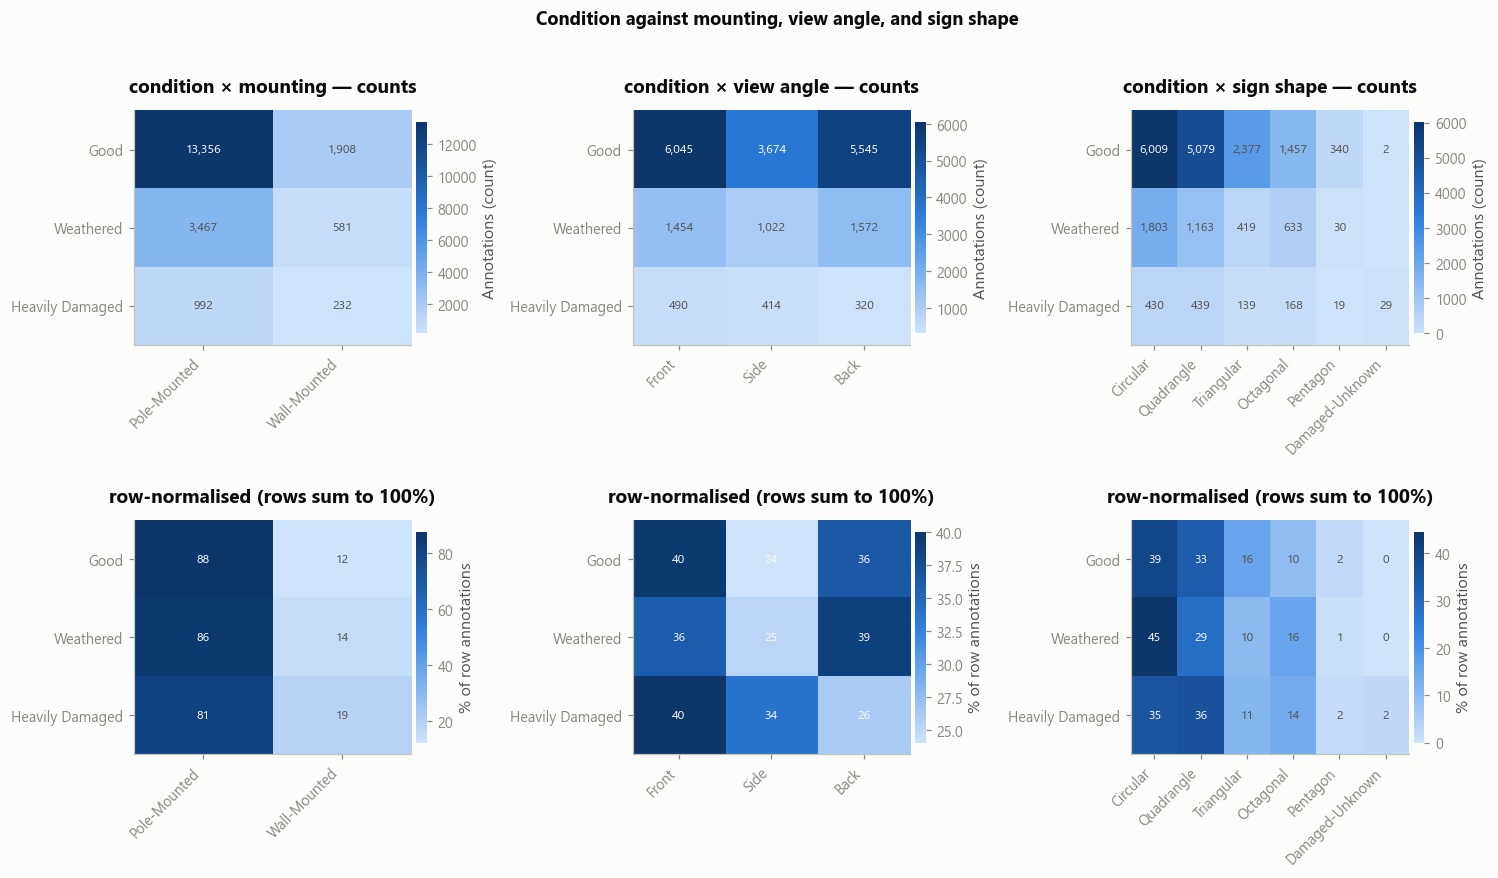

Good             -> most common mounting: Pole-Mounted (87.5% of Good annotations)
Weathered        -> most common mounting: Pole-Mounted (85.7% of Weathered annotations)
Heavily Damaged  -> most common mounting: Pole-Mounted (81.0% of Heavily Damaged annotations)

Good             -> most common view angle: Front (39.6% of Good annotations)
Weathered        -> most common view angle: Back (38.8% of Weathered annotations)
Heavily Damaged  -> most common view angle: Front (40.0% of Heavily Damaged annotations)

Good             -> most common sign shape: Circular (39.4% of Good annotations)
Weathered        -> most common sign shape: Circular (44.5% of Weathered annotations)
Heavily Damaged  -> most common sign shape: Quadrangle (35.9% of Heavily Damaged annotations)



In [33]:
ATTRIBUTE_PAIRS = [("condition", "mounting"), ("condition", "view_angle"),
                   ("condition", "sign_shape"), ("mounting", "sign_shape"),
                   ("view_angle", "sign_shape")]
attr_ct = {}
for a, b in ATTRIBUTE_PAIRS:
    ct = annlib.crosstab_matrices(qa_anns, a, b)
    attr_ct[(a, b)] = ct
    ct["counts"].to_csv(config.CSV_DIR / f"attribute_cooccurrence_{a}_{b}.csv")
    ct["row_pct"].to_csv(config.CSV_DIR / f"attribute_cooccurrence_{a}_{b}_row_percentages.csv")

condition_pairs = [(a, b) for a, b in ATTRIBUTE_PAIRS if a == "condition"]
fig, axes = plt.subplots(2, 3, figsize=(15.6, 7.6), gridspec_kw={"wspace": 0.5, "hspace": 0.75})
for col, (a, b) in enumerate(condition_pairs):
    ct = attr_ct[(a, b)]
    plotstyle.heatmap(axes[0, col], ct["counts"], fmt="{:,.0f}",
                      cbar_label="Annotations (count)")
    axes[0, col].set_title(f"{a} × {b.replace('_', ' ')} — counts")
    plotstyle.heatmap(axes[1, col], ct["row_pct"], fmt="{:.0f}", hide_zeros=False,
                      cbar_label="% of row annotations")
    axes[1, col].set_title("row-normalised (rows sum to 100%)")
fig.suptitle("Condition against mounting, view angle, and sign shape",
             fontweight="bold", y=1.0)
plotstyle.save_fig(fig, "fig29_condition_attribute_pairs")
plt.show()

for a, b in condition_pairs:
    row_pct = attr_ct[(a, b)]["row_pct"]
    for value in row_pct.index:
        top = row_pct.loc[value].idxmax()
        print(f"{value:<16} -> most common {b.replace('_', ' ')}: "
              f"{top} ({row_pct.loc[value, top]:.1f}% of {value} annotations)")
    print()


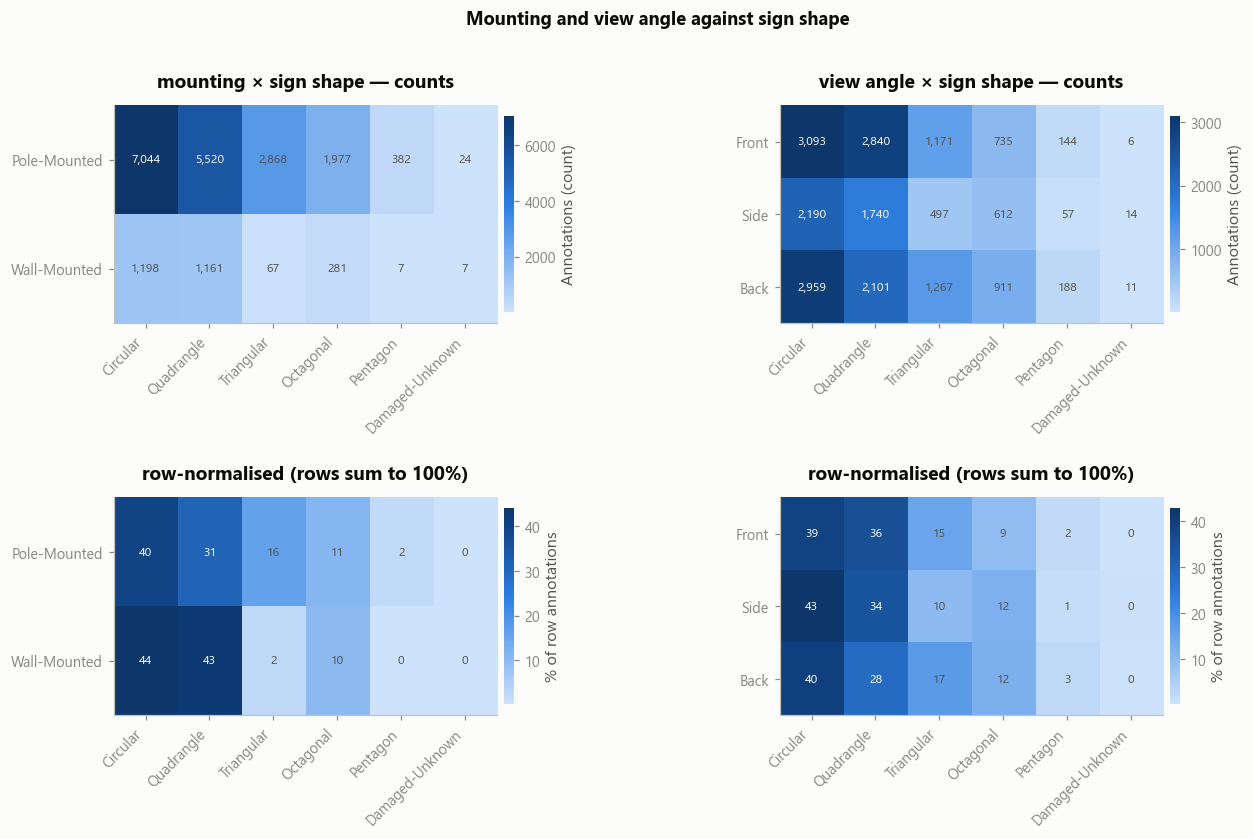

In [34]:
shape_pairs = [("mounting", "sign_shape"), ("view_angle", "sign_shape")]
fig, axes = plt.subplots(2, 2, figsize=(13.2, 7.2), gridspec_kw={"wspace": 0.45, "hspace": 0.8})
for col, (a, b) in enumerate(shape_pairs):
    ct = attr_ct[(a, b)]
    plotstyle.heatmap(axes[0, col], ct["counts"], fmt="{:,.0f}",
                      cbar_label="Annotations (count)")
    axes[0, col].set_title(f"{a.replace('_', ' ')} × sign shape — counts")
    plotstyle.heatmap(axes[1, col], ct["row_pct"], fmt="{:.0f}", hide_zeros=False,
                      cbar_label="% of row annotations")
    axes[1, col].set_title("row-normalised (rows sum to 100%)")
fig.suptitle("Mounting and view angle against sign shape", fontweight="bold", y=1.0)
plotstyle.save_fig(fig, "fig30_shape_attribute_pairs")
plt.show()


### 7.8 Geographic distribution of annotations

Annotations are connected to the image inventory's EXIF GPS fixes through the
`(source group, file name)` pair — a join validated as strictly one-to-one, so no
annotation can be duplicated or double-counted. Only fixes inside the Malta bounding box
count as *valid GPS*; coverage (and therefore how representative this section can be) is
reported first and exported to `annotation_gps_coverage.csv`.

**Locality assignment is nearest-centroid, not point-in-polygon.** The repository contains
approximate town-centre coordinates (`mtsd_eda.geo`) but no administrative boundary
polygons, so each image is assigned to the closest of ~80 locality centroids. Near
locality borders this can mis-assign points; distances to the matched centroid are small
(median well under 1 km) but the caveat stands. A proper spatial join would require Malta
locality boundary data (e.g. the NSO/ERA Local Administrative Units polygons as GeoJSON,
or OSM `admin_level=8` boundaries for Malta). The pipeline is modular: swapping
`geo.assign_localities` for a polygon join upgrades every table and chart below without
further changes. **No locality is ever guessed or invented** — every name comes from the
fixed reference list in `mtsd_eda.geo`.

Because localities that were photographed more simply contain more signs, raw counts and
proportions are always reported together, and localities with fewer than
`MIN_LOCALITY_ANNOTATIONS` annotated signs are flagged (`low_sample`) rather than ranked
on their percentages. Unit: annotations, except `geotagged_images`/`annotated_images`
columns (images).


In [35]:
image_geo = annlib.annotated_image_geo(qa_images, qa_anns, inv)
gps_cov = annlib.gps_coverage_table(image_geo)
gps_cov.to_csv(config.CSV_DIR / "annotation_gps_coverage.csv", index=False)
display(gps_cov.style.hide(axis="index"))

geo_anns = annlib.annotation_geo(qa_anns, image_geo)
print(f"Annotations in the geographic frame : {len(geo_anns):,}")
print(f"Localities represented              : {geo_anns['locality'].nunique()} "
      f"(of {len(geo.locality_frame())} reference centroids)")
print(f"Distance to matched centroid        : median "
      f"{geo_anns['locality_distance_km'].median():.2f} km, "
      f"p95 {geo_anns['locality_distance_km'].quantile(0.95):.2f} km")


Metric,Value,Unit
Annotated images,"7,490",images
Annotated images with valid GPS,"4,226 (56.4%)",images
Annotated images without usable GPS,"3,264 (43.6%)",images
of which GPS present but outside Malta bounds,0,images
Annotations in geographic analysis,"11,339 (55.2%)",annotations
Annotations excluded (no valid GPS),"9,197 (44.8%)",annotations


Annotations in the geographic frame : 11,339
Localities represented              : 50 (of 79 reference centroids)
Distance to matched centroid        : median 0.51 km, p95 1.11 km


locality,district,geotagged_images,annotated_images,annotations,distinct_classes,n_Good,pct_Good,n_Weathered,pct_Weathered,n_Heavily Damaged,pct_Heavily Damaged,low_sample
Mosta,Northern,548,548,2198,11,1959,89.130000,196,8.920000,43,1.960000,False
Zurrieq,South Eastern,355,355,1078,11,810,75.140000,214,19.850000,54,5.010000,False
Sliema,Northern Harbour,402,402,735,11,455,61.900000,224,30.480000,56,7.620000,False
Msida,Northern Harbour,209,209,565,11,370,65.490000,157,27.790000,38,6.730000,False
Qormi,Northern Harbour,197,197,546,12,457,83.700000,80,14.650000,9,1.650000,False
Fgura,Southern Harbour,136,136,444,11,312,70.270000,95,21.400000,37,8.330000,False
Rabat (Malta),Western,191,191,420,11,240,57.140000,139,33.100000,41,9.760000,False
Senglea,Southern Harbour,127,127,410,11,299,72.930000,82,20.000000,29,7.070000,False
Safi,South Eastern,104,104,321,10,239,74.450000,68,21.180000,14,4.360000,False
Attard,Western,160,160,319,11,204,63.950000,76,23.820000,39,12.230000,False


Full ranked table (50 localities, 8 flagged low-sample) -> locality_annotation_summary.csv


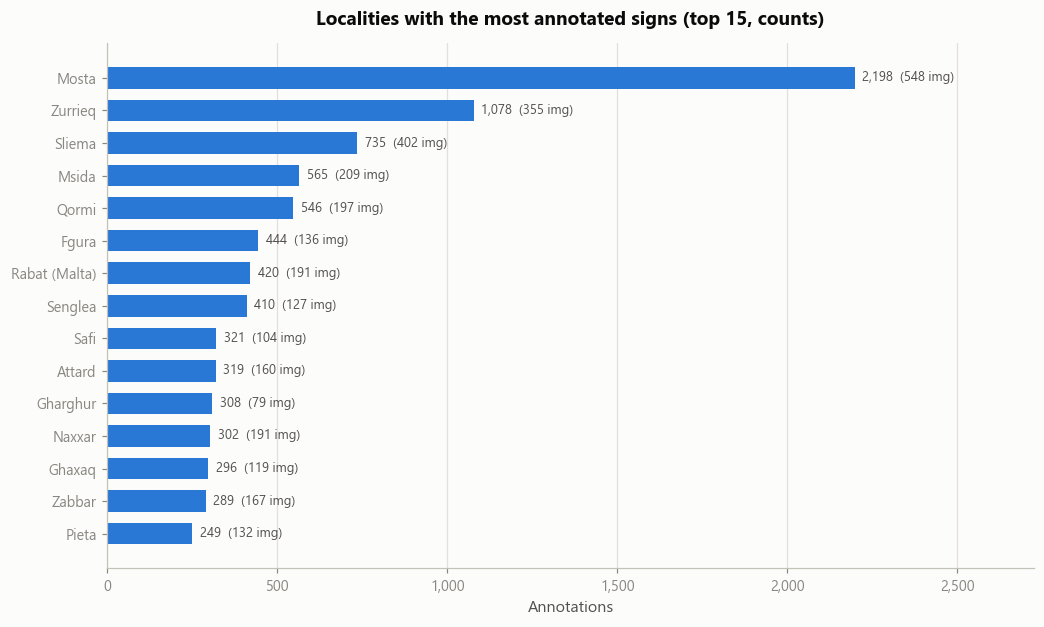

In [36]:
locality_ann = annlib.locality_annotation_summary(
    geo_anns, image_geo, min_annotations=MIN_LOCALITY_ANNOTATIONS)
locality_ann.to_csv(config.CSV_DIR / "locality_annotation_summary.csv", index=False)
display(locality_ann.head(15).style.hide(axis="index"))
print(f"Full ranked table ({len(locality_ann)} localities, "
      f"{int(locality_ann['low_sample'].sum())} flagged low-sample) -> "
      f"locality_annotation_summary.csv")

top = locality_ann.head(15)
fig, ax = plt.subplots(figsize=(9.6, 5.8))
bars = ax.barh(top["locality"][::-1], top["annotations"][::-1],
               color=plotstyle.ACCENT, height=0.66)
for bar, (_, row) in zip(bars, top[::-1].iterrows()):
    ax.annotate(f"{row['annotations']:,}  ({row['annotated_images']:,} img)",
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=plotstyle.INK_SECONDARY)
plotstyle.style_h_barh(ax)
ax.set_title("Localities with the most annotated signs (top 15, counts)")
ax.set_xlabel("Annotations")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.24)
fig.tight_layout()
plotstyle.save_fig(fig, "fig31_locality_annotations")
plt.show()


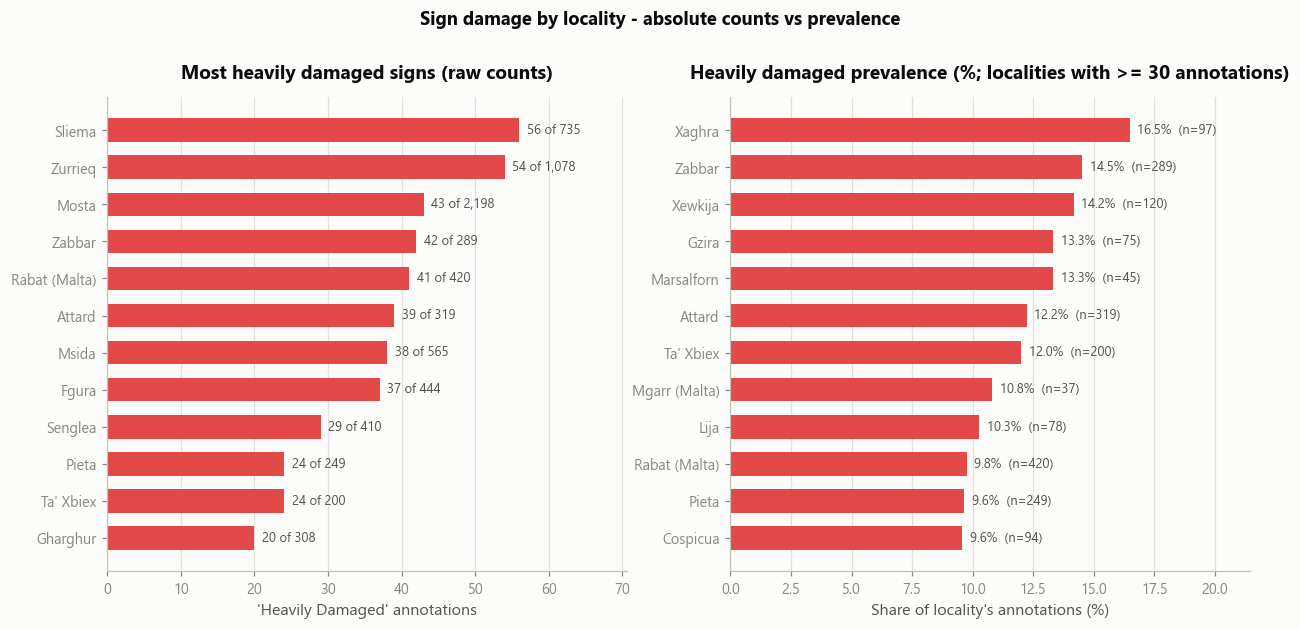

Most 'Weathered' signs : Sliema (224), Zurrieq (214), Mosta (196), Msida (157), Rabat (Malta) (139)
Weathered prevalence   : St Julian's (55.6%), Mdina (35.6%), Gzira (34.7%), Zebbiegh (34.4%), Marsalforn (33.3%)


In [37]:
damaged_col, weathered_col = "n_Heavily Damaged", "n_Weathered"
if damaged_col not in locality_ann.columns:
    print("No 'Heavily Damaged' condition value in the current QA exports - "
          "damage ranking skipped.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.6))

    by_count = locality_ann.nlargest(12, damaged_col)
    bars = axes[0].barh(by_count["locality"][::-1], by_count[damaged_col][::-1],
                        color=plotstyle.CATEGORICAL[5], height=0.64)
    for bar, (_, row) in zip(bars, by_count[::-1].iterrows()):
        axes[0].annotate(f"{int(row[damaged_col]):,} of {row['annotations']:,}",
                         (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                         xytext=(5, 0), textcoords="offset points",
                         va="center", fontsize=8.5, color=plotstyle.INK_SECONDARY)
    plotstyle.style_h_barh(axes[0])
    axes[0].set_title("Most heavily damaged signs (raw counts)")
    axes[0].set_xlabel("'Heavily Damaged' annotations")
    axes[0].margins(x=0.26)

    # Prevalence view: percentage of a locality's signs that are heavily damaged,
    # restricted to localities above the minimum-sample threshold.
    eligible = locality_ann[~locality_ann["low_sample"]]
    by_pct = eligible.nlargest(12, "pct_Heavily Damaged")
    bars = axes[1].barh(by_pct["locality"][::-1], by_pct["pct_Heavily Damaged"][::-1],
                        color=plotstyle.CATEGORICAL[5], height=0.64)
    for bar, (_, row) in zip(bars, by_pct[::-1].iterrows()):
        axes[1].annotate(f"{row['pct_Heavily Damaged']:.1f}%  (n={row['annotations']:,})",
                         (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                         xytext=(5, 0), textcoords="offset points",
                         va="center", fontsize=8.5, color=plotstyle.INK_SECONDARY)
    plotstyle.style_h_barh(axes[1])
    axes[1].set_title(f"Heavily damaged prevalence (%; localities with >= "
                      f"{MIN_LOCALITY_ANNOTATIONS} annotations)")
    axes[1].set_xlabel("Share of locality's annotations (%)")
    axes[1].margins(x=0.30)

    fig.suptitle("Sign damage by locality - absolute counts vs prevalence",
                 fontweight="bold", y=1.02)
    plotstyle.save_fig(fig, "fig32_locality_damage")
    plt.show()

    top_weathered = locality_ann.nlargest(5, weathered_col)
    print("Most 'Weathered' signs :",
          ", ".join(f"{r['locality']} ({int(r[weathered_col]):,})"
                    for _, r in top_weathered.iterrows()))
    top_wpct = eligible.nlargest(5, "pct_Weathered")
    print("Weathered prevalence   :",
          ", ".join(f"{r['locality']} ({r['pct_Weathered']:.1f}%)"
                    for _, r in top_wpct.iterrows()))


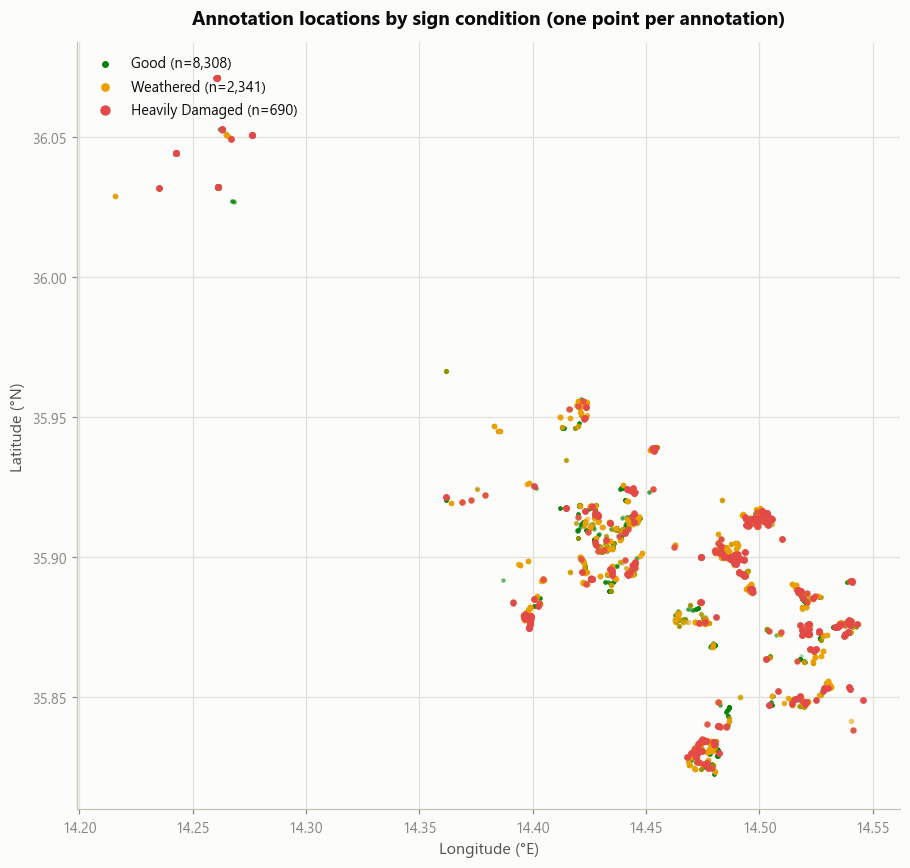

A locality-level choropleth needs administrative boundary polygons, which the repository does not include; see the note at the top of this subsection.


In [38]:
# One point per annotation at its image's GPS fix; severer conditions drawn on
# top so sparse damage is not hidden under the dense 'Good' layer.
condition_order = annlib.ordered_values(geo_anns, "condition")
palette = [plotstyle.CATEGORICAL[3], plotstyle.CATEGORICAL[2], plotstyle.CATEGORICAL[5],
           plotstyle.CATEGORICAL[4]]
styles = {value: {"color": palette[min(i, len(palette) - 1)],
                  "size": 8 + 5 * i, "alpha": min(0.35 + 0.25 * i, 0.85)}
          for i, value in enumerate(condition_order)}

fig, ax = plt.subplots(figsize=(9.2, 8.0))
for value in condition_order:
    sub = geo_anns[geo_anns["condition"] == value]
    style = styles[value]
    ax.scatter(sub["gps_longitude"], sub["gps_latitude"], s=style["size"],
               color=style["color"], alpha=style["alpha"], linewidth=0,
               label=f"{value} (n={len(sub):,})")
ax.set_aspect(1 / np.cos(np.radians(35.9)))
ax.set_title("Annotation locations by sign condition (one point per annotation)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
legend = ax.legend(loc="upper left", frameon=False, markerscale=1.6)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
fig.tight_layout()
plotstyle.save_fig(fig, "fig33_condition_map")
plt.show()

print("A locality-level choropleth needs administrative boundary polygons, which the "
      "repository does not include; see the note at the top of this subsection.")


### 7.9 Annotation quality and consistency checks

Automated, **strictly read-only** validation of the QA exports — this notebook never
edits, removes, or repairs an annotation; corrections belong to the separate
annotation-QA workflow. Checks cover: degenerate, negative-coordinate, out-of-bounds,
suspiciously small, and duplicated boxes; orphan annotations; unannotated images; missing
or null auxiliary attributes; unexpected attribute values; invalid category ids and blank
category names; two-way reconciliation between the QA files and the images on disk; and
annotations whose source image cannot be resolved. The zero/non-zero count of every check
is exported to `annotation_qc_summary.csv`; non-empty offender tables additionally go to
`annotation_qc_<check>.csv` for follow-up.


In [39]:
qc = coco.annotation_quality_report(qa_images, qa_anns, inventory=inv, categories=qa_cats)

qc_summary = pd.DataFrame(
    [(name, len(frame)) for name, frame in qc.items()],
    columns=["check", "findings"],
)
qc_summary.to_csv(config.CSV_DIR / "annotation_qc_summary.csv", index=False)
display(qc_summary.assign(check=qc_summary["check"].str.replace("_", " "))
        .style.hide(axis="index"))

for name, frame in qc.items():
    if len(frame):
        frame.to_csv(config.CSV_DIR / f"annotation_qc_{name}.csv", index=False)
        print(f"\n--- {name} ({len(frame)} findings, first 5) " + "-" * 30)
        display(frame.head(5))


check,findings
degenerate boxes,0
negative coordinate boxes,0
out of bounds boxes,0
suspiciously small boxes,1
duplicate boxes,2
orphan annotations,0
images without annotations,2
missing attributes,0
unexpected attribute values,0
invalid category ids,0



--- suspiciously_small_boxes (1 findings, first 5) ------------------------------


,annotation_uid,image_uid,category_name,bbox_x,bbox_y,bbox_w,bbox_h,image_width,image_height
13989,13990,5200,Pedestrian Crossing,983.13,1060.86,2.01,1.83,3000.0,4000.0



--- duplicate_boxes (2 findings, first 5) ------------------------------


,annotation_uid,image_uid,category_name,bbox_x,bbox_y,bbox_w,bbox_h,image_width,image_height
8771,8772,3206,Other-Unknown,0.0,3241.89,34.84,120.58,3072.0,4080.0
8778,8779,3206,Other-Unknown,0.0,3241.89,34.84,120.58,3072.0,4080.0



--- images_without_annotations (2 findings, first 5) ------------------------------


,image_uid,file_name,source_group
4417,4418,a3907179-IMG_2260.JPG,GRP-7
4588,4589,debd8cdb-IMG_2261.JPG,GRP-7


### 7.10 Duplicate image detection

Perceptual difference hashes (dHash, 64-bit) flag visually identical or near-identical
images across the whole corpus — including re-exports whose bytes differ (recompression,
metadata stripping) but whose content is the same. Pairs at Hamming distance 0 are
byte-level or recompression duplicates; small non-zero distances usually indicate edited
variants of the same capture.


In [40]:
near_dupes = inventory.find_near_duplicates(inv, max_distance=NEAR_DUPLICATE_BITS)
exact = near_dupes[near_dupes["hamming_distance"] == 0]

print(f"Near-duplicate pairs (<= {NEAR_DUPLICATE_BITS} bits): {len(near_dupes)}")
print(f"  of which visually exact (0 bits)   : {len(exact)}")
if len(near_dupes):
    near_dupes.to_csv(config.CSV_DIR / "near_duplicate_images.csv", index=False)
    display(near_dupes.head(12))


Near-duplicate pairs (<= 2 bits): 12
  of which visually exact (0 bits)   : 11


,file_a,file_b,group_a,group_b,hamming_distance,same_file_size
0,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
1,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
2,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
3,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
4,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
5,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
6,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
7,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
8,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False
9,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,Datasets/MTSD/GRP-10/merged_images/WhatsApp Im...,GRP-10,GRP-10,0,False


## 8. Dataset summary and discussion

The table below consolidates the headline statistics computed throughout the notebook; the
narrative that follows interprets them for the dissertation.


In [41]:
key_stats = pd.DataFrame(
    [
        ("Images on disk", f"{len(inv):,}"),
        ("Total volume", f"{inv['file_size_bytes'].sum() / 1024**3:,.2f} GiB"),
        ("Unreadable images", f"{int(inv['is_corrupted'].sum()):,}"),
        ("EXIF coverage", f"{readable['has_exif'].mean():.1%}"),
        ("GPS coverage", f"{readable['has_gps'].mean():.1%}"),
        ("Median resolution", f"{readable['width'].median():.0f}×{readable['height'].median():.0f} px"),
        ("Median megapixels", f"{readable['megapixels'].median():.1f} MP"),
        ("Portrait orientation", f"{(readable['orientation'] == 'portrait').mean():.1%}"),
        ("Device manufacturers", f"{readable['make_norm'].nunique()}"),
        ("Distinct camera models", f"{readable['camera_model'].nunique()}"),
        ("Capture window", capture_window),
        ("Localities reached", f"{locality_summary['locality'].nunique()}"),
        ("QA-verified images", f"{len(qa_images):,}"),
        ("QA-verified annotations", f"{len(qa_anns):,}"),
        ("Annotation classes", f"{len(qa_cats)}"),
        ("Boxes per image (mean)", f"{per_image.mean():.2f}"),
        ("Class imbalance ratio", f"{imbalance['imbalance_ratio']:.0f} : 1"),
        ("Gini coefficient (classes)", f"{imbalance['gini_coefficient']:.2f}"),
        ("Small objects (COCO)", f"{(qa_anns['size_class'].cat.codes == 0).mean():.1%}"),
        ("Median relative box area", f"{qa_anns['rel_area'].median():.3%}"),
        ("Signs not in good condition", f"{weathered_share:.1%}"),
        ("Annotated images with valid GPS",
         f"{int(image_geo.loc[image_geo['annotation_count'] > 0, 'gps_valid'].sum()):,}"
         f" ({image_geo.loc[image_geo['annotation_count'] > 0, 'gps_valid'].mean():.1%})"),
        ("Localities with annotated signs", f"{len(locality_ann)}"),
        ("Near-duplicate pairs", f"{len(near_dupes)}"),
    ],
    columns=["Statistic", "Value"],
)
key_stats.to_csv(config.CSV_DIR / "dataset_key_statistics.csv", index=False)
key_stats.style.hide(axis="index")


Statistic,Value
Images on disk,"7,492"
Total volume,20.76 GiB
Unreadable images,0
EXIF coverage,76.9%
GPS coverage,56.4%
Median resolution,3024×4032 px
Median megapixels,12.2 MP
Portrait orientation,97.3%
Device manufacturers,5
Distinct camera models,34


In [42]:
display(Markdown(f"""
### Strengths

- **Verified ground truth.** Every annotation has passed a manual QA pass; the automated
  consistency checks in §7.9 found no degenerate or out-of-bounds geometry, and QA files
  reconcile exactly with the images on disk.
- **Rich metadata.** {readable['has_exif'].mean():.0%} of images carry full EXIF and
  {readable['has_gps'].mean():.0%} carry GPS, enabling the spatial and temporal analyses
  above and supporting stratified evaluation by device, place, and time.
- **Device diversity.** {readable['camera_model'].nunique()} camera models from
  {readable['make_norm'].nunique()} manufacturers guard against single-sensor overfitting.
- **Auxiliary attributes.** Per-box view angle, mounting, condition, and shape allow
  fine-grained error analysis unusual for datasets of this size.
- **High resolution.** A median of {readable['megapixels'].median():.0f} MP preserves the
  fine detail of distant signs, which matters given the small-object share.

### Limitations and potential biases

- **Class imbalance.** A long-tailed distribution ({imbalance['imbalance_ratio']:.0f}:1
  head-to-tail; the top class alone holds {imbalance['top1_share_pct']:.0f}% of instances)
  will require re-weighting, resampling, or loss shaping during training.
- **Viewpoint bias.** Captures are pedestrian, deliberately framed
  ({(readable['orientation'] == 'portrait').mean():.0%} portrait; box centres cluster in the
  central third of the frame), so models trained on MTSD may transfer imperfectly to
  vehicle-mounted, landscape-framed cameras.
- **Temporal concentration.** The campaign spans {span_days} days in a single season,
  limiting seasonal and rare-weather variation; {timed['hour'].between(7, 17).mean():.0%}
  of captures are daytime.
- **Geographic concentration.** Coverage follows the collectors' routes; several localities
  dominate while others are sparsely represented (§5), so spatially stratified splits are
  advisable.
- **Metadata gaps.** {1 - readable['has_exif'].mean():.0%} of images lack EXIF (mostly
  messaging-app re-exports), and the near-duplicate scan flagged {len(near_dupes)} pairs
  that should be de-duplicated or forced into the same split to avoid leakage.

### Implications for model development

1. Evaluation should report per-class metrics and COCO size-stratified AP, given the
   imbalance and the {(qa_anns['size_class'].cat.codes == 0).mean():.0%} small-object share.
2. Train/validation/test splits should be grouped by capture location and near-duplicate
   cluster to prevent spatial and duplicate leakage.
3. The condition attribute supports robustness studies on weathered signage
   ({weathered_share:.0%} of instances) — a distinctive contribution of this dataset.
"""))



### Strengths

- **Verified ground truth.** Every annotation has passed a manual QA pass; the automated
  consistency checks in §7.9 found no degenerate or out-of-bounds geometry, and QA files
  reconcile exactly with the images on disk.
- **Rich metadata.** 77% of images carry full EXIF and
  56% carry GPS, enabling the spatial and temporal analyses
  above and supporting stratified evaluation by device, place, and time.
- **Device diversity.** 34 camera models from
  5 manufacturers guard against single-sensor overfitting.
- **Auxiliary attributes.** Per-box view angle, mounting, condition, and shape allow
  fine-grained error analysis unusual for datasets of this size.
- **High resolution.** A median of 12 MP preserves the
  fine detail of distant signs, which matters given the small-object share.

### Limitations and potential biases

- **Class imbalance.** A long-tailed distribution (204:1
  head-to-tail; the top class alone holds 33% of instances)
  will require re-weighting, resampling, or loss shaping during training.
- **Viewpoint bias.** Captures are pedestrian, deliberately framed
  (97% portrait; box centres cluster in the
  central third of the frame), so models trained on MTSD may transfer imperfectly to
  vehicle-mounted, landscape-framed cameras.
- **Temporal concentration.** The campaign spans 87 days in a single season,
  limiting seasonal and rare-weather variation; 96%
  of captures are daytime.
- **Geographic concentration.** Coverage follows the collectors' routes; several localities
  dominate while others are sparsely represented (§5), so spatially stratified splits are
  advisable.
- **Metadata gaps.** 23% of images lack EXIF (mostly
  messaging-app re-exports), and the near-duplicate scan flagged 12 pairs
  that should be de-duplicated or forced into the same split to avoid leakage.

### Implications for model development

1. Evaluation should report per-class metrics and COCO size-stratified AP, given the
   imbalance and the 10% small-object share.
2. Train/validation/test splits should be grouped by capture location and near-duplicate
   cluster to prevent spatial and duplicate leakage.
3. The condition attribute supports robustness studies on weathered signage
   (26% of instances) — a distinctive contribution of this dataset.


## 9. Exported artefacts

Every figure and table generated by this notebook, for direct inclusion in the dissertation.


In [43]:
artefacts = []
for folder, kind in ((config.FIGURES_DIR, "figure"), (config.CSV_DIR, "table")):
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artefacts.append({"kind": kind, "file": path.name,
                              "size_kb": round(path.stat().st_size / 1024, 1)})
artefact_frame = pd.DataFrame(artefacts)
print(f"{len(artefact_frame)} artefacts in {config.EDA_DIR}")
artefact_frame


102 artefacts in E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA


,kind,file,size_kb
0,figure,fig01_formats_and_file_size.png,99.3
1,figure,fig02_resolution_landscape.png,227.3
2,figure,fig03_geometry_profile.png,123.7
3,figure,fig04_manufacturers.png,76.4
4,figure,fig05_camera_models.png,148.8
...,...,...,...
97,table,resolution_bucket_summary.csv,0.1
98,table,resolution_summary.csv,4.6
99,table,temporal_summary.csv,1.3
100,table,timeline_summary.csv,0.1
